# 📓 EDIS 8100 · Week 5 · Mini Project 2: What Are Students Actually Saying?

### Text-Based Analytics and Natural Language Processing on a Discussion Forum

**Estimated time:** about 60 minutes for the core path (run every cell top to bottom), plus your own time for the interpretation memo. We launch it together in class on Wednesday, September 23, 2026, and you finish it before the Canvas deadline.

**Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

*Guest speaker this week: Jiayi (Joyce) Zhang, University of Pennsylvania.*

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Build** a text analysis pipeline on real discussion prose: clean, tokenize, count, and say out loud what each cleaning decision deleted from the record.
2. **Score** sentiment with a lexicon small enough to read in full, then diagnose where that lexicon is measuring the topic instead of the stance.
3. **Fit and compare** two topic models (NMF and LDA) on the same corpus, and interpret their topics against what the course actually discussed, without pretending the models handed you labels.
4. **Tag** discourse moves (question, agreement, counterpoint, evidence citing, connecting) with transparent rules, check the rules against the posts by hand, and report how often they are wrong.
5. **Adjudicate** a genuine disagreement between methods and defend the reading you chose, in writing, to an audience that can check your work.

---

## How this notebook works (read this if you are new to code)

- Click a cell and press **Shift + Enter** to run it. Work from the top down. Cells lower in the notebook depend on the ones above them.
- **Nothing here can break your computer, your grade, or the course repository.** The notebook writes its own data into a temporary folder. If you would like to keep your edits, use **File > Save a copy in Drive** in Colab first.
- If something goes sideways, the fix is almost always **Runtime > Restart and run all**. Start from the top and let it go.
- Cells marked **✏️ Your turn** are yours to edit. Every one of them already contains a working answer, so the notebook runs correctly even if you change nothing. You are editing a working thing, not filling a hole.
- You will see red or pink warning text sometimes. Warnings are not errors. Only a message that says `Error` or `Traceback` needs your attention.
- Ask your neighbor before you ask the internet, and ask the instructor before you spend twenty minutes stuck.

---

## What you are doing this week, in one paragraph

You have a forum with 1,456 posts written by undergraduates in a course about learning how to learn. Nobody has time to read all of it, which is exactly the situation that makes text analytics tempting. So you will build the standard pipeline, one honest step at a time, and then you will do the part that most tutorials skip: you will put three methods next to each other, find the places where they contradict one another, and decide which one you believe. The deliverable is not the pipeline. The deliverable is the defended reading.

## ⚙️ Setup: run the next cell first

The cell below builds this week's datasets right inside your session: `students.csv`, `forum_posts.csv`, and `gradebook.csv`. Nothing is downloaded, so this works in Colab, on your laptop, and on the classroom wifi at 4:45 on a Wednesday.

The data are synthetic on purpose. Learning analytics is usually practiced on records belonging to people who never got asked, and a course assignment is a poor reason to read a real student's discussion posts. So we invented the course instead, which means we can rehearse the judgment without surveilling anyone. The ask in return: treat these posts as if a real person wrote them, because the habits you build here are the habits you will carry into work where a real person did.

In [1]:
# ============================================================================
# SETUP CELL: builds this week's synthetic datasets.
# This cell is long. You do not need to read it, and you will not be asked
# about it. It lives here so the notebook runs anywhere with no downloads,
# no logins, and no network access. Run it, collapse it (click the little
# arrow to the left of the cell), and move on to Section 1.
# ============================================================================

"""EDIS 8100 data generation, the subset needed for week05.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GRADEBOOK = SEED + 2
SEED_FORUM = SEED + 3
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
WEEK_TOPICS = {
    1: "memory",
    2: "spacing",
    3: "metacognition",
    4: "motivation",
    5: "collaboration",
    6: "note-taking",
    7: "sleep",
    8: "test anxiety",
}
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
TOPIC_BANKS = {
    "memory": {
        "concepts": [
            "retrieval practice", "the forgetting curve", "encoding versus retrieval",
            "chunking", "the testing effect", "elaborative interrogation",
            "cue dependent forgetting", "the difference between recall and recognition",
        ],
        "claims": [
            "recognizing material is not the same as being able to recall it",
            "retrieval practice does more for me than rereading ever did",
            "the effort that feels unproductive is often the effort that works",
            "working memory limits explain why cramming feels productive and then fails",
            "expert memory is mostly organized knowledge rather than raw capacity",
            "how we encode something decides what cues will bring it back later",
        ],
        "practices": [
            "closing the book and writing down everything I could recall",
            "drawing the diagram from memory before checking my notes",
            "quizzing myself on the vocabulary instead of highlighting it",
            "explaining the model out loud to my roommate",
            "starting each session with five minutes of blank page recall",
            "turning the section headings into questions and answering them",
        ],
        "outcomes": [
            "the gaps in my understanding showed up immediately",
            "I was surprised by how much I had already lost",
            "it took longer but it stuck for the whole week",
            "I could rebuild the structure but not the specific numbers",
            "my confidence dropped and my actual scores went up",
            "the second attempt was noticeably easier than the first",
        ],
        "contexts": [
            "my anatomy course", "a statistics class I took last year",
            "the certification exam I am studying for", "my seminar readings",
            "an intro chemistry sequence", "the language class I am taking",
        ],
        "qualifiers": [
            "most of the studies used word lists rather than course material",
            "the effect might be smaller when the material is genuinely new to you",
            "students who already know the content have less to retrieve",
            "the discomfort makes it hard to keep doing on a busy week",
            "we never see how long the advantage lasts past a semester",
            "the classroom studies had far messier results than the lab ones",
        ],
        "questions": [
            "Does anyone else find retrieval practice uncomfortable at first?",
            "How do you use recall for conceptual material rather than definitions?",
            "Has anyone tried this with a partner instead of alone?",
            "Is there a point where self testing starts giving you false confidence?",
            "What do you do when you cannot recall anything at all?",
            "Would this work the same way for skills rather than facts?",
        ],
    },
    "spacing": {
        "concepts": [
            "distributed practice", "the spacing effect", "interleaving",
            "massed practice", "review scheduling", "desirable difficulty",
            "the lag effect", "retention interval",
        ],
        "claims": [
            "spacing wins even when total study time is held constant",
            "cramming buys performance today and borrows it from next month",
            "interleaving feels worse during practice and better on the test",
            "the optimal gap depends on how long you need to hold the material",
            "our sense of how well we are learning is a poor guide to scheduling",
            "spacing is less about willpower and more about calendar design",
        ],
        "practices": [
            "spreading my review over four short sessions instead of one long one",
            "mixing problem types in a single set instead of blocking them",
            "scheduling a ten minute review the morning after each lecture",
            "putting review blocks in my calendar the way I schedule classes",
            "revisiting week one material during week four",
            "keeping a running list of topics due for another pass",
        ],
        "outcomes": [
            "the material felt less familiar each time and I retained more",
            "my week stopped ending in panic",
            "the fourth pass took almost no time at all",
            "I noticed which topics kept slipping and could target them",
            "it felt inefficient and the quiz said otherwise",
            "I stopped rereading things I already knew cold",
        ],
        "contexts": [
            "a summer course that moved very fast", "my licensure exam prep",
            "the two courses I am taking back to back", "a research methods class",
            "my part time job schedule", "a course with weekly quizzes",
        ],
        "qualifiers": [
            "spacing assumes you have control over your own schedule",
            "students working long hours cannot always choose their gaps",
            "the studies rarely say what to do when the exam is in three days",
            "interleaving needs enough material to interleave in the first place",
            "the recommended gaps in the literature vary quite a lot",
            "it is hard to separate spacing from simply studying more often",
        ],
        "questions": [
            "How far apart do your review sessions actually end up being?",
            "Does interleaving still help when the problem types look identical?",
            "What do you do when the schedule collapses in a heavy week?",
            "Has anyone found a way to make spacing feel less pointless early on?",
            "Do you space by topic or by course?",
            "Is there a version of this that works for writing rather than problem sets?",
        ],
    },
    "metacognition": {
        "concepts": [
            "judgments of learning", "calibration", "monitoring and control",
            "the illusion of fluency", "self explanation", "planning and reflection",
            "overconfidence in familiar material", "the study plan nobody follows",
        ],
        "claims": [
            "we are confident about exactly the things we have not learned",
            "monitoring is worthless if it never changes what you do next",
            "fluency during reading gets mistaken for knowing the material",
            "asking why after each paragraph changes what you notice",
            "good learners are not smarter so much as better calibrated",
            "reflection has to be specific enough to point at a next action",
        ],
        "practices": [
            "predicting my quiz score before submitting and checking it after",
            "writing one sentence about what confused me at the end of each session",
            "rating my confidence on each problem before looking at the answer",
            "asking myself why a step works before moving on",
            "keeping a short log of what I planned and what I actually did",
            "stopping every ten minutes to summarize without looking",
        ],
        "outcomes": [
            "my predictions were about eight points too generous every time",
            "the reflection took two minutes and changed my next session",
            "I found out I was confident and wrong in the same places",
            "the log made my avoidance patterns embarrassingly visible",
            "I started catching confusion earlier instead of at the exam",
            "my confidence ratings slowly became more accurate",
        ],
        "contexts": [
            "a course where I had no background", "my thesis writing",
            "a coding class", "the statistics unit", "an online module",
            "a lab section with weekly reports",
        ],
        "qualifiers": [
            "self report is exactly the measure we are trying to improve",
            "reflection prompts get gamed once students know they are graded",
            "calibration studies usually use short retention intervals",
            "some of this may just be conscientiousness under another name",
            "it is unclear how much of this transfers across subjects",
            "the effect could be a byproduct of spending more time overall",
        ],
        "questions": [
            "How accurate are your own predictions of your performance?",
            "Does reflection help if nobody ever reads it?",
            "What is the smallest monitoring habit that has worked for you?",
            "Can a dashboard support calibration or does it replace it?",
            "How do you tell useful confusion from unproductive confusion?",
            "Should reflection be graded at all?",
        ],
    },
    "motivation": {
        "concepts": [
            "expectancy value theory", "self efficacy", "mastery goals",
            "autonomy support", "interest development", "cost appraisals",
            "attribution after a bad grade", "the difference between interest and utility",
        ],
        "claims": [
            "cost is the part of the motivation equation we ignore most",
            "self efficacy is built from experience and not from encouragement",
            "performance goals help until the first bad grade arrives",
            "interest can be developed and is not only something you arrive with",
            "autonomy matters more when the task is genuinely difficult",
            "telling a student to try harder tells them nothing about how",
        ],
        "practices": [
            "writing down why the unit connects to work I actually care about",
            "breaking the assignment into pieces small enough to start",
            "tracking my wins for a week instead of my failures",
            "choosing the paper topic myself instead of taking the default",
            "asking my instructor what a strong answer looks like",
            "starting with the part of the problem set I can already do",
        ],
        "outcomes": [
            "the assignment stopped feeling like one giant block",
            "I noticed how much of my avoidance was about cost and not interest",
            "my first draft finally happened",
            "the connection was thin but it was enough to start",
            "I felt more in control even though the work was the same",
            "the small wins mattered more than I expected",
        ],
        "contexts": [
            "a required course outside my field", "an early morning section",
            "a class where I felt behind from week one", "my capstone project",
            "a course with only two grades all semester", "the online section",
        ],
        "qualifiers": [
            "motivation research often measures intentions rather than behavior",
            "structural constraints get relabeled as motivation problems",
            "a student working thirty hours a week is not lacking grit",
            "the interventions that work in one course often fail in another",
            "self report measures are collected right after the intervention",
            "we rarely see what happens to motivation a year later",
        ],
        "questions": [
            "Where do you see cost showing up in your own courses?",
            "Can an analytics dashboard support motivation without shaming anyone?",
            "How do you rebuild self efficacy after a bad exam?",
            "What does autonomy support look like in a large lecture?",
            "Is interest something a course can actually design for?",
            "Do mastery goals survive contact with a curve?",
        ],
    },
    "collaboration": {
        "concepts": [
            "transactive discussion", "group regulation", "productive friction",
            "free riding", "role assignment", "shared mental models",
            "socially shared regulation", "who gets listened to in a group",
        ],
        "claims": [
            "groups get smarter when disagreement is about ideas and not people",
            "equal talk time is not the same thing as equal contribution",
            "the group that plans first usually finishes with less rework",
            "roles help until they become an excuse to stop listening",
            "one dominant voice can hide four people who understood more",
            "building on someone else's idea is a skill that has to be taught",
        ],
        "practices": [
            "starting our session with two minutes of silent individual writing",
            "assigning a rotating facilitator each week",
            "restating the previous person's point before adding mine",
            "putting our disagreements in the shared doc instead of resolving them fast",
            "asking the quietest person for their read before we decided",
            "leaving the first ten minutes for planning rather than drafting",
        ],
        "outcomes": [
            "our artifact was better and the session felt slower",
            "two people who had said nothing turned out to have the key objection",
            "we stopped redoing each other's work",
            "the conversation got sharper once we wrote first",
            "we finished early and the quality did not suffer",
            "the disagreement turned out to be about definitions",
        ],
        "contexts": [
            "our studio group", "a lab team of four", "a semester long design project",
            "a class where groups were assigned randomly", "an online group",
            "a group where two of us knew each other already",
        ],
        "qualifiers": [
            "talk time is easy to measure and easy to overinterpret",
            "quiet does not mean disengaged in every culture or every group",
            "our data cannot see who did the thinking between sessions",
            "group grades hide enormous variation inside the group",
            "the same group behaves differently on a task they care about",
            "a single session is a very thin slice of a collaboration",
        ],
        "questions": [
            "How would you measure contribution without privileging talk?",
            "What should a collaboration dashboard refuse to show the group?",
            "Has role assignment ever backfired in your experience?",
            "How do you surface a quiet objection without putting someone on the spot?",
            "Is productive friction something you can design for?",
            "What counts as an idea unit if the idea arrives in three fragments?",
        ],
    },
    "note-taking": {
        "concepts": [
            "generative note-taking", "verbatim transcription", "the encoding function",
            "the storage function", "concept mapping", "revision passes",
            "selectivity while listening", "what notes are actually for",
        ],
        "claims": [
            "notes that are complete are often notes that were never processed",
            "the encoding benefit happens while you write and not while you read",
            "reviewing notes without transforming them does very little",
            "handwriting helps mainly because it forces you to be selective",
            "the best notes are the ones you rewrite badly and then fix",
            "note structure should mirror the structure of the argument",
        ],
        "practices": [
            "leaving a wide margin for questions I write after class",
            "rewriting my lecture notes as a concept map that evening",
            "limiting myself to one page per lecture on purpose",
            "writing a three sentence summary at the bottom of each page",
            "coding my notes for claims, evidence, and open questions",
            "comparing my notes with a classmate the next day",
        ],
        "outcomes": [
            "my notes got shorter and much more useful",
            "the summary was where I discovered what I had missed",
            "I stopped transcribing and started listening",
            "the map showed two ideas I had recorded as unrelated",
            "the margin questions became my study guide",
            "our two versions disagreed in an informative way",
        ],
        "contexts": [
            "a fast lecture course", "a seminar with dense readings",
            "a class where slides were posted afterward", "my methods course",
            "a course taught mostly through examples", "an online asynchronous class",
        ],
        "qualifiers": [
            "the laptop versus longhand studies have not replicated cleanly",
            "the right strategy depends on whether slides are available",
            "students with accommodations may need transcription and that is fine",
            "note quality is hard to score reliably",
            "most studies look at one lecture rather than a semester",
            "we cannot see what students do with notes after the study ends",
        ],
        "questions": [
            "What does your revision pass actually look like?",
            "Does concept mapping help you or slow you down?",
            "How do you take notes on a reading that is already well organized?",
            "Do posted slides change what you should write?",
            "Has anyone found a note system that survives a heavy week?",
            "Should we teach note-taking explicitly in first year courses?",
        ],
    },
    "sleep": {
        "concepts": [
            "memory consolidation", "sleep debt", "circadian timing",
            "slow wave sleep", "social jetlag", "attention lapses",
            "the tradeoff between one more hour and one more cycle", "sleep as a study strategy",
        ],
        "claims": [
            "the last two hours of studying are often worth less than the sleep they cost",
            "consolidation is part of learning and not a break from it",
            "sleep debt shows up as attention lapses long before it feels like fatigue",
            "an early class schedule fights the circadian rhythm of most undergraduates",
            "napping helps but does not repay a week of short nights",
            "we treat sleep as a lifestyle choice when it is a study strategy",
        ],
        "practices": [
            "moving my last study block an hour earlier for two weeks",
            "putting my phone across the room after eleven",
            "protecting seven hours on the nights before quizzes",
            "reviewing the hardest material right before sleeping",
            "keeping a fixed wake time even on weekends",
            "trading my late night session for an early morning one",
        ],
        "outcomes": [
            "my afternoon focus improved more than my evening focus did",
            "I lost an hour of studying and gained a much better quiz",
            "the first week was rough and the second was clearly better",
            "I stopped rereading the same paragraph four times",
            "my weekend recovery sleep stopped wrecking Monday",
            "the difference was smaller than I hoped but it was real",
        ],
        "contexts": [
            "a semester with two early classes", "my night shift job",
            "finals week", "a course with Tuesday deadlines",
            "the weeks I was commuting", "a stretch when I had a newborn at home",
        ],
        "qualifiers": [
            "sleep advice assumes a schedule that many students do not control",
            "the correlational studies cannot separate sleep from stress",
            "self reported sleep is not very accurate",
            "caregiving and shift work make fixed schedules impossible",
            "the lab studies use young adults with no other obligations",
            "telling a working student to sleep more can land as a judgment",
        ],
        "questions": [
            "How do you protect sleep in a week with three deadlines?",
            "Has anyone actually shifted their schedule and kept it?",
            "Should a learning analytics system ever collect sleep data?",
            "What would you do with sleep data if you had it?",
            "Is the tradeoff different for problem sets versus writing?",
            "How do you talk about sleep without moralizing about it?",
        ],
    },
    "test anxiety": {
        "concepts": [
            "worry versus emotionality", "working memory load", "stereotype threat",
            "expressive writing", "reappraisal", "practice testing under pressure",
            "what a single high stakes exam measures", "arousal as information",
        ],
        "claims": [
            "anxiety consumes the working memory the test is trying to measure",
            "the worry component predicts performance more than the physical symptoms",
            "reappraising arousal as readiness changes performance without changing the feeling",
            "low stakes practice testing lowers the stakes of the real thing",
            "test anxiety is partly a signal about how the assessment is designed",
            "students who feel underprepared and students who are underprepared are different groups",
        ],
        "practices": [
            "writing about my worries for ten minutes before the exam",
            "taking a full practice test under timed conditions",
            "reframing my racing heart as my body getting ready",
            "arriving early enough to stop rushing",
            "starting with the question I know I can answer",
            "planning what I would do if I blanked on the first page",
        ],
        "outcomes": [
            "the writing did not calm me down but my score went up",
            "the practice test was awful and the real one was manageable",
            "I stopped spiraling after the first hard question",
            "my hands still shook and I finished the exam",
            "the plan mattered more than the calm",
            "it helped less than I hoped but it did help",
        ],
        "contexts": [
            "a high stakes licensure exam", "my first graduate statistics midterm",
            "a course where one exam was sixty percent of the grade",
            "an oral exam", "a timed coding assessment", "the final in my methods course",
        ],
        "qualifiers": [
            "some of these interventions were tested only in single sessions",
            "the effects are much smaller outside psychology labs",
            "an anxious student in a badly designed assessment is responding rationally",
            "we should probably fix the assessment before fixing the student",
            "expressive writing has had mixed replication results",
            "anxiety measures are collected right after a stressful event",
        ],
        "questions": [
            "Where does test anxiety come from in the courses you have taught?",
            "Would more frequent low stakes quizzes help or add pressure?",
            "Has reappraisal worked for anyone here?",
            "How should an early warning system talk to an anxious student?",
            "Is anxiety a student problem or an assessment design problem?",
            "What would you change about the assessment itself?",
        ],
    },
}
OPENERS_ROOT = [
    "I have been thinking about {concept} since the reading.",
    "This week's material on {concept} landed differently than I expected.",
    "I want to open a thread on {concept}.",
    "Something about {concept} has been nagging at me all week.",
    "I came into this week fairly skeptical about {concept}.",
    "The section on {concept} was the part I understood least.",
    "Quick question for the group about {concept}.",
    "Reading about {concept} made me rethink how I study.",
    "I keep circling back to the discussion of {concept}.",
]
OPENERS_REPLY = [
    "I agree with the earlier point about {concept}, but I want to push on one piece.",
    "This thread is helping me see {concept} more clearly.",
    "Building on the post above, I think {concept} is doing a lot of work here.",
    "I read that section on {concept} differently.",
    "Adding a small counterexample to what has been said about {concept}.",
    "Yes to all of this, and I want to add one thing about {concept}.",
    "I am not sure I follow the argument about {concept} yet.",
    "Coming back to an earlier comment on {concept}.",
    "This framing of {concept} lines up with my own experience.",
    "I had the opposite reaction to the claim about {concept}.",
    "Thank you for naming what bothered me about {concept}.",
    "I want to sit with the point about {concept} for a second.",
    "Two people above have said something useful about {concept}.",
    "I will take the other side on {concept}, mostly to see what happens.",
]
CLAIM_FRAMES = [
    "My takeaway is that {claim}.",
    "The reading argues that {claim}, and I think that is right.",
    "What seems clear to me is that {claim}.",
    "I keep coming back to the idea that {claim}.",
    "If I followed the chapter, {claim}.",
    "The part that convinced me is that {claim}.",
    "I would say {claim}, at least for the kind of material we work with.",
    "It looks like {claim}, though the evidence is not airtight.",
    "The strongest version of the argument is that {claim}.",
    "What I did not expect was the claim that {claim}.",
    "The authors seem to be saying that {claim}.",
    "Stated plainly, {claim}.",
]
EVIDENCE_FRAMES = [
    "Last week I tried {practice}, and {outcome}.",
    "When I started {practice}, {outcome}.",
    "I tested this on myself by {practice}, and {outcome}.",
    "In {context} I have been {practice}, and {outcome}.",
    "I gave {practice} an honest try, and {outcome}.",
    "The first time I tried {practice} it felt slow, but {outcome}.",
    "During {context} I ended up {practice}, and {outcome}.",
    "I spent two weeks {practice}, and {outcome}.",
    "Something similar happened in {context} when I was {practice}, since {outcome}.",
]
QUALIFIER_FRAMES = [
    "That said, {qualifier}.",
    "The caveat for me is that {qualifier}.",
    "One limit worth naming is that {qualifier}.",
    "I am holding this loosely, because {qualifier}.",
    "It is worth remembering that {qualifier}.",
    "Where I get stuck is that {qualifier}.",
    "I would want to know more before generalizing, since {qualifier}.",
    "My hesitation is that {qualifier}.",
    "This is probably context dependent, given that {qualifier}.",
]
GENERIC_QUESTION_FRAMES = [
    "How would you explain {concept} to a first year student?",
    "Where does {concept} break down in your experience?",
    "Would you design a course around {concept}?",
    "What would change your mind about {concept}?",
    "How would you even measure {concept} in a real classroom?",
    "Does {concept} look different in an online course?",
    "Who benefits when we take {concept} seriously, and who does not?",
    "What would you want to see before you trusted {concept}?",
]
POSITIVE_TAILS = [
    "Honestly, this was the most useful reading of the semester so far.",
    "I appreciated how concrete the examples were.",
    "This one actually changed something about my week, which is rare.",
    "Great thread, everyone.",
    "I am excited to try this in my own teaching.",
    "This clarified something I had been confused about for years.",
    "I liked that the authors admitted what they could not explain.",
    "This is the first reading that felt written for practitioners.",
    "Really glad this was assigned.",
    "I have already sent this one to a colleague.",
    "The examples were the best part for me.",
    "I finished this feeling more hopeful than I expected.",
    "Thanks to whoever picked this reading.",
    "This gave me language for something I had only felt.",
]
NEGATIVE_TAILS = [
    "I found this reading frustrating and a little discouraging.",
    "I am struggling to see how any of this survives a real classroom.",
    "This felt disconnected from the students I actually work with.",
    "I am worried we are asking students to fix a system problem.",
    "I left this reading more confused than when I started.",
    "The tone bothered me, even if the findings hold up.",
    "I wanted the authors to say what they would actually do on Monday.",
    "The sample felt too narrow for the size of the claim.",
    "This one wore me out, to be honest.",
    "I kept waiting for the part about resources and it never came.",
    "I am skeptical, and I am open to being talked out of it.",
    "The writing made a simple idea feel complicated.",
    "This landed as advice for students who already have time.",
    "I finished this a little annoyed, which may be my own week talking.",
]
def _compose_post(rng, topic: str, is_reply: bool) -> str:
    bank = TOPIC_BANKS[topic]
    parts = []

    def a_question() -> str:
        if rng.random() < 0.45:
            return str(rng.choice(GENERIC_QUESTION_FRAMES)).format(
                concept=str(rng.choice(bank["concepts"]))
            )
        return str(rng.choice(bank["questions"]))

    opener_bank = OPENERS_REPLY if is_reply else OPENERS_ROOT
    if is_reply or rng.random() < 0.85:
        parts.append(str(rng.choice(opener_bank)).format(concept=str(rng.choice(bank["concepts"]))))

    parts.append(str(rng.choice(CLAIM_FRAMES)).format(claim=str(rng.choice(bank["claims"]))))

    if rng.random() < 0.62:
        parts.append(
            str(rng.choice(EVIDENCE_FRAMES)).format(
                practice=str(rng.choice(bank["practices"])),
                outcome=str(rng.choice(bank["outcomes"])),
                context=str(rng.choice(bank["contexts"])),
            )
        )
    if rng.random() < 0.48:
        parts.append(
            str(rng.choice(QUALIFIER_FRAMES)).format(qualifier=str(rng.choice(bank["qualifiers"])))
        )
    if rng.random() < 0.55:
        parts.append(a_question())

    tail_roll = rng.random()
    if tail_roll < 0.13:
        parts.append(str(rng.choice(POSITIVE_TAILS)))
    elif tail_roll < 0.22:
        parts.append(str(rng.choice(NEGATIVE_TAILS)))

    if len(parts) < 2:
        parts.append(a_question())
    return " ".join(parts[:6])
def make_forum(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Threaded discussion forum, one topic per course week.

    The reply structure is the point (P4). Students belong to one of three loose
    conversational clusters and almost always reply inside their own cluster.
    Four students reply across clusters far more often. Those four end up with
    high betweenness and only middling degree, which is exactly the pattern the
    week 8 network lab asks students to find and interpret.
    """
    rng = np.random.default_rng(SEED_FORUM)
    students = make_students(write=False)
    n = len(students)

    sid = students["student_id"].to_numpy()
    community = students["community"].to_numpy()
    connector = students["connector"].to_numpy()
    silent = students["silent_forum"].to_numpy()
    fprop = students["forum_propensity"].to_numpy()

    # Posting propensity. Silent students are close to invisible on the forum,
    # which is the missingness students will have to reckon with.
    weight = np.exp(0.72 * fprop)
    weight = np.where(silent == 1, weight * 0.05, weight)
    # Connectors post a steady, unremarkable two replies a week. Their influence
    # comes from who they answer, not from how loud they are.
    weight = np.where(connector == 1, 0.0, weight)
    weight = weight / weight.sum()

    cross_p = np.where(connector == 1, 0.90, 0.010)

    conn_idx = np.where(connector == 1)[0]
    # Each connector keeps up a friendship with a few people in the other two
    # clusters. Those repeated ties are the bridges the whole network runs on.
    bridge_partners = {}
    for c in conn_idx:
        pool = np.where((community != community[c]) & (silent == 0) & (connector == 0))[0]
        bridge_partners[int(c)] = set(int(x) for x in rng.choice(pool, size=3, replace=False))

    posts = []
    thread_counter = 0
    post_counter = 0

    for week in range(1, N_WEEKS + 1):
        topic = WEEK_TOPICS[week]
        n_posts = int(rng.integers(165, 205))
        n_threads = int(rng.integers(6, 10))

        week_posts = []  # (post_id, thread_id, author_idx, seconds)
        week_start_s = (week - 1) * 7 * DAY_S

        reply_authors = [int(c) for c in conn_idx for _ in range(2)]
        n_replies = n_posts - n_threads
        reply_authors += list(
            rng.choice(n, size=max(0, n_replies - len(reply_authors)), p=weight)
        )
        rng.shuffle(reply_authors)

        for t in range(n_threads):
            author = int(rng.choice(n, p=weight))
            thread_counter += 1
            post_counter += 1
            thread_id = f"TH{thread_counter:03d}"
            post_id = f"F{post_counter:04d}"
            day = float(rng.uniform(0.2, 2.6))
            hour = float(np.clip(rng.normal(15.0, 3.2), 7.5, 23.5))
            secs = week_start_s + day * DAY_S + hour * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": thread_id,
                    "parent_post_id": "",
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=False),
                }
            )
            week_posts.append((post_id, thread_id, author, secs))

        for author in reply_authors:
            same_comm = rng.random() >= cross_p[author]
            candidates = [
                p for p in week_posts
                if p[2] != author
                and ((community[p[2]] == community[author]) == same_comm)
            ]
            if not candidates:
                candidates = [p for p in week_posts if p[2] != author]
            if not candidates:
                continue
            # Prefer recent posts, which produces plausible thread growth.
            ages = np.array([week_posts[-1][3] - c[3] for c in candidates])
            w = np.exp(-ages / (1.6 * DAY_S)) + 0.08
            if author in bridge_partners and not same_comm:
                boost = np.array(
                    [40.0 if c[2] in bridge_partners[author] else 1.0 for c in candidates]
                )
                w = w * boost
            else:
                # Connectors spend their time answering other people rather than
                # collecting answers, so fewer replies land on their posts.
                w = w * np.array([0.30 if connector[c[2]] == 1 else 1.0 for c in candidates])
            w = w / w.sum()
            parent = candidates[int(rng.choice(len(candidates), p=w))]

            post_counter += 1
            post_id = f"F{post_counter:04d}"
            gap = float(rng.gamma(1.6, 5.5)) * 3600.0
            # Keep the thread inside its own week without letting late replies
            # pile up on the closing instant. Saturating the gap against the
            # room that is left leaves short gaps untouched (1 - exp(-x) is x
            # for small x) and squeezes only the long tail, so a reply always
            # lands strictly after the post it answers.
            room = week_start_s + 6.9 * DAY_S - parent[3]
            if room > 1.0:
                gap = room * (1.0 - float(np.exp(-gap / room)))
                # 1 - exp(-x) saturates to exactly 1.0 in float64, so hold a
                # second back to keep room for whoever replies next.
                gap = min(gap, room - 1.0)
            else:
                gap = 1.0
            secs = parent[3] + gap
            hour_of_day = (secs % DAY_S) / 3600.0
            if hour_of_day < 7.0:
                secs += (8.0 - hour_of_day) * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": parent[1],
                    "parent_post_id": parent[0],
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=True),
                }
            )
            week_posts.append((post_id, parent[1], author, secs))

    # Timestamps are written to whole seconds, so a very short gap could still
    # round a reply onto its parent. Walk the posts in creation order (a parent
    # is always created before its replies) and push any collision one second
    # out. The nudge is at most a second per post, well inside the week.
    at_secs = {}
    for p in posts:
        p["_secs"] = float(np.round(p["_secs"]))
        parent_id = p["parent_post_id"]
        if parent_id:
            p["_secs"] = max(p["_secs"], at_secs[parent_id] + 1.0)
        at_secs[p["post_id"]] = p["_secs"]

    df = pd.DataFrame(posts)
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["post_id", "thread_id", "parent_post_id", "student_id", "week", "timestamp", "text"]]
    if write:
        df.to_csv(_outpath(outdir, "forum_posts.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_forum(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)

Data ready. Files created in ./data:
   forum_posts.csv
   gradebook.csv
   students.csv


Now the tools. Four libraries, all of them already installed in Colab: **pandas** for tables, **numpy** for arrays and arithmetic, **matplotlib** for figures, and **scikit-learn** for the vectorizers and the two topic models. There is nothing to install and nothing to download, which is a deliberate design choice: an analysis that only runs on a machine with the right downloads is an analysis your reader cannot check.

In [2]:
%matplotlib inline

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.autolayout': True,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RANDOM_STATE = 8100   # the course seed, so your figures match your neighbor's

print('Libraries loaded. pandas', pd.__version__, '| numpy', np.__version__)

Libraries loaded. pandas 2.2.2 | numpy 1.26.4


---

## 📊 1. Meet the corpus

Before any modeling, look at the thing. A corpus is not an abstraction: it is a pile of sentences that people wrote, and the first job is to know how big the pile is, who is in it, and who is missing.

`forum_posts.csv` has one row per post. `week` matters more than it looks: the course ran one discussion topic per week, in this order, and that gives us a rare luxury. We have a **ground truth** to check our topic models against. Most of the time you do not, which is the whole reason topic model interpretation is hard.

| Week | Topic |
|---|---|
| 1 | memory |
| 2 | spacing |
| 3 | metacognition |
| 4 | motivation |
| 5 | collaboration |
| 6 | note taking |
| 7 | sleep |
| 8 | test anxiety |

In [3]:
posts = pd.read_csv('data/forum_posts.csv')
students = pd.read_csv('data/students.csv')

WEEK_TOPICS = {
    1: 'memory', 2: 'spacing', 3: 'metacognition', 4: 'motivation',
    5: 'collaboration', 6: 'note taking', 7: 'sleep', 8: 'test anxiety',
}
posts['topic_label'] = posts['week'].map(WEEK_TOPICS)

print('posts:', posts.shape, '| columns:', list(posts.columns))
print('students on the roster:', len(students))
print('students who posted at least once:', posts['student_id'].nunique())
print('students who never posted:', len(students) - posts['student_id'].nunique())
print()
print('Post length in characters:')
print(posts['text'].str.len().describe().round(1).to_string())
print()
print('--- one whole post, exactly as written ---')
print(posts.loc[0, 'text'])

posts: (1456, 8) | columns: ['post_id', 'thread_id', 'parent_post_id', 'student_id', 'week', 'timestamp', 'text', 'topic_label']
students on the roster: 120
students who posted at least once: 102
students who never posted: 18

Post length in characters:
count    1456.0
mean      353.1
std        94.2
min       134.0
25%       288.0
50%       360.0
75%       421.0
max       608.0

--- one whole post, exactly as written ---
Quick question for the group about cue dependent forgetting. I keep coming back to the idea that the effort that feels unproductive is often the effort that works. I tested this on myself by turning the section headings into questions and answering them, and the gaps in my understanding showed up immediately.


Eighteen students never wrote a single post. Hold onto that number. Every method in this notebook analyzes the posts that exist, which means every claim you make is a claim about the 102 people who spoke. It is very easy to write "students found the spacing readings frustrating" when what you mean is "of the people who chose to post, the ones who used certain words." Silence is data, and text analytics cannot see it.

Now, how much text do we have per week, and does any week dominate?

      posts  authors  mean_chars          topic
week                                           
1       195       76       355.8         memory
2       189       78       355.1        spacing
3       177       74       360.3  metacognition
4       165       68       350.3     motivation
5       174       79       355.6  collaboration
6       190       75       338.2    note taking
7       196       76       360.9          sleep
8       170       79       348.4   test anxiety


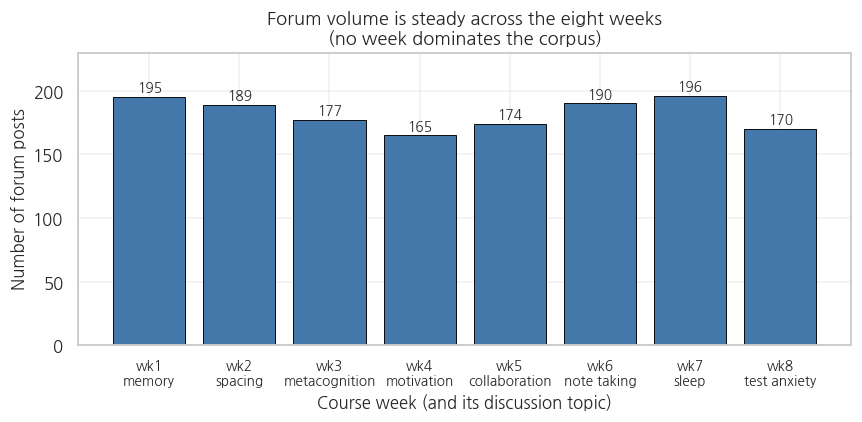

In [4]:
by_week = posts.groupby('week').agg(
    posts=('post_id', 'size'),
    authors=('student_id', 'nunique'),
    mean_chars=('text', lambda s: s.str.len().mean()),
).round(1)
by_week['topic'] = by_week.index.map(WEEK_TOPICS)
print(by_week.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_week.index, by_week['posts'], color='#4477AA', edgecolor='black', linewidth=0.6)
ax.set_xticks(list(by_week.index))
ax.set_xticklabels([f"wk{w}\n{WEEK_TOPICS[w]}" for w in by_week.index], fontsize=9)
ax.set_xlabel('Course week (and its discussion topic)')
ax.set_ylabel('Number of forum posts')
ax.set_title('Forum volume is steady across the eight weeks\n(no week dominates the corpus)')
ax.set_ylim(0, 230)
for w, n in zip(by_week.index, by_week['posts']):
    ax.text(w, n + 4, str(n), ha='center', fontsize=9)
plt.show()

**🧠 Interpret this chart before you move on.** Volume is nearly flat: every week contributes between 165 and 196 posts, so no single topic will swamp a model just by being bigger. That is convenient, and it is also unusual. Write yourself one sentence: if week 4 had produced 600 posts and week 6 had produced 40, what would that have done to a topic model fit on all eight weeks at once? (Answer it now. It will matter in Section 5.)

---

## 📊 2. Cleaning and tokenizing, and a receipt for what you deleted

"Cleaning" is a friendly word for *deleting evidence*. Every standard step lowercases, strips punctuation, splits on whitespace, and throws away common words. Each of those is a decision, each decision removes something, and the removed thing is invisible in every chart you make afterward.

So we are going to do the cleaning, and then we are going to print the receipt.

Watch one post go through the stages first.

In [5]:
def clean_text(s):
    """Lowercase, replace anything that is not a letter or space with a space, squeeze spaces."""
    s = s.lower()
    s = re.sub(r"[^a-z\s]", ' ', s)
    s = re.sub(r"\s+", ' ', s).strip()
    return s

example = posts.loc[3, 'text']

print('STAGE 0 raw:')
print(' ', example)
print()
print('STAGE 1 lowercased:')
print(' ', example.lower()[:180], '...')
print()
cleaned_example = clean_text(example)
print('STAGE 2 punctuation removed:')
print(' ', cleaned_example[:180], '...')
print()
tokens_example = cleaned_example.split()
print('STAGE 3 tokenized ->', len(tokens_example), 'tokens. First 20:')
print(' ', tokens_example[:20])
print()
kept = [t for t in tokens_example if t not in ENGLISH_STOP_WORDS]
print('STAGE 4 stopwords removed ->', len(kept), 'tokens remain. First 20:')
print(' ', kept[:20])

STAGE 0 raw:
  I keep circling back to the discussion of cue dependent forgetting. Stated plainly, working memory limits explain why cramming feels productive and then fails. The first time I tried starting each session with five minutes of blank page recall it felt slow, but the gaps in my understanding showed up immediately. What would you want to see before you trusted the forgetting curve?

STAGE 1 lowercased:
  i keep circling back to the discussion of cue dependent forgetting. stated plainly, working memory limits explain why cramming feels productive and then fails. the first time i tri ...

STAGE 2 punctuation removed:
  i keep circling back to the discussion of cue dependent forgetting stated plainly working memory limits explain why cramming feels productive and then fails the first time i tried  ...

STAGE 3 tokenized -> 63 tokens. First 20:
  ['i', 'keep', 'circling', 'back', 'to', 'the', 'discussion', 'of', 'cue', 'dependent', 'forgetting', 'stated', 'plainly', 'working', 

Now the receipt at the corpus level. Two questions: how much of the text did we throw away, and *what exactly* went in the bin?

In [6]:
posts['clean'] = posts['text'].apply(clean_text)

# What punctuation carried meaning?
n_question_marks = posts['text'].str.count(r'\?').sum()
posts_with_q = (posts['text'].str.contains(r'\?')).mean()

all_tokens = [t for doc in posts['clean'] for t in doc.split()]
dropped = [t for t in all_tokens if t in ENGLISH_STOP_WORDS]
survived = [t for t in all_tokens if t not in ENGLISH_STOP_WORDS]

print('Tokens after punctuation removal :', f'{len(all_tokens):,}')
print('Tokens deleted as stopwords      :', f'{len(dropped):,}',
      f'({len(dropped) / len(all_tokens):.1%} of the corpus)')
print('Tokens that survived             :', f'{len(survived):,}')
print()
print('Question marks destroyed by cleaning:', f'{n_question_marks:,}',
      f'  (they appeared in {posts_with_q:.1%} of posts)')
print()
print('The 12 words we deleted most often:')
print(pd.Series(dropped).value_counts().head(12).to_string())

Tokens after punctuation removal :

90,862
Tokens deleted as stopwords      : 50,705 (55.8% of the corpus)
Tokens that survived             : 40,157

Question marks destroyed by cleaning: 804   (they appeared in 55.2% of posts)

The 12 words we deleted most often:
the      5217
i        3654
is       2122
that     2120
to       2106
and      1843
a        1719
of       1316
about    1217
my       1063
what     1016
on        926


Fifty-six percent of the corpus is gone, and all 804 question marks in the forum went with it. Before you shrug at that: in Section 6 the way we detect a *question* is by looking for a question mark. If we had run the rest of this notebook on the cleaned column, that entire discourse move would have become undetectable, and we would never have seen an error message about it. The analysis would simply have reported that nobody asks questions.

This is the single most important habit in text analytics: **keep the raw text and choose, per analysis, which version to feed it.** We will tag discourse moves on `text` (raw) and model topics on `clean`.

There is a second problem, and it is worse, because scikit-learn's default English stopword list is doing something you would not expect.

In [7]:
check = ['not', 'no', 'never', 'nothing', 'but', 'however', 'although',
         'interest', 'less', 'same', 'above', 'agree', 'yes', 'because']
report = pd.DataFrame({
    'word': check,
    'in_sklearn_stoplist': [w in ENGLISH_STOP_WORDS for w in check],
    'times_in_corpus': [sum(t == w for t in all_tokens) for w in check],
})
print(report.to_string(index=False))
print()
print('Size of the sklearn stoplist:', len(ENGLISH_STOP_WORDS), 'words')
print()
print('Sentence surgery, live:')
demo = 'I do not agree with the authors, however I am not sure the study shows what they claim.'
print('  before:', demo)
print('  after :', ' '.join(t for t in clean_text(demo).split() if t not in ENGLISH_STOP_WORDS))

    word  in_sklearn_stoplist  times_in_corpus
     not                 True              833
      no                 True               42
   never                 True               98
 nothing                 True               44
     but                 True              334
 however                 True                0
although                 True                0
interest                 True              115
    less                 True              165
    same                 True              136
   above                 True              203
   agree                False               94
     yes                False               92
 because                 True              124

Size of the sklearn stoplist: 318 words

Sentence surgery, live:
  before: I do not agree with the authors, however I am not sure the study shows what they claim.
  after : agree authors sure study shows claim


**🧠 Interpret this table.** The default stoplist removes `not`, `no`, `never`, `but`, `however`, and `although`. Look at the demo sentence: "I do not agree with the authors, however I am not sure the study shows what they claim" becomes "agree authors sure study shows claim." A negation-free, objection-free version of a post that was an objection.

Write down what this implies for the next two sections. A word-frequency chart built on this cleaning cannot see disagreement. A sentiment lexicon applied after this cleaning would score that sentence as positive. That is not a bug in scikit-learn: `stop_words='english'` is documented as a crude default, and the documentation says so. It is a bug in an analyst who accepts a default without reading it.

### ✏️ Your turn 1: decide what counts as a stopword

Below, `MY_EXTRA_STOPWORDS` is a small list of words that are frequent in this particular corpus but tell us nothing about *which week* a post came from ("week", "reading", "material"). Corpus-specific stopwords are a normal and defensible move, and they are also a way to quietly delete inconvenient evidence, so they belong in your methods section.

The list already works as written, so you can run the cell untouched. Then try adding or removing a word and see what changes.

In [8]:
# TODO (optional): add or remove words. Keep it a list of lowercase strings.
MY_EXTRA_STOPWORDS = ['week', 'reading', 'material', 'thing', 'really']

MY_STOPWORDS = set(ENGLISH_STOP_WORDS) | set(MY_EXTRA_STOPWORDS)

before = pd.Series([t for t in all_tokens if t not in ENGLISH_STOP_WORDS]).value_counts().head(10)
after = pd.Series([t for t in all_tokens if t not in MY_STOPWORDS]).value_counts().head(10)

comparison = pd.DataFrame({'default stoplist': before.index, 'count_a': before.values,
                           'your stoplist': after.index, 'count_b': after.values})
print('Top 10 surviving words, side by side:')
print(comparison.to_string(index=False))
print()
print('Words your additions removed from the top 10:',
      sorted(set(before.index) - set(after.index)) or 'none')

Top 10 surviving words, side by side:
default stoplist  count_a your stoplist  count_b
            want      414          want      414
            week      369          work      340
        material      355          said      339
            work      340          does      322
            said      339         sleep      307
            does      322         notes      279
           sleep      307          time      274
           notes      279           did      263
            time      274        coming      250
             did      263       earlier      248

Words your additions removed from the top 10: ['material', 'week']


---

## 📊 3. Word frequencies with CountVectorizer

`CountVectorizer` turns a list of documents into a **document-term matrix**: one row per post, one column per word, and each entry is a count. It is the least glamorous object in natural language processing and almost everything else is built on it.

Two settings do real work here, and they are choices, not defaults you should ignore:

- `min_df=5` drops any word appearing in fewer than 5 posts. This kills typos and one-off proper nouns, and it also kills the vocabulary of anyone whose way of talking is rare in this room. That is a trade with an equity dimension: rare words often belong to people who are rare here.
- `max_df=0.5` drops any word appearing in more than half of all posts. Those words cannot distinguish anything.

In [9]:
count_vec = CountVectorizer(stop_words=sorted(MY_STOPWORDS), min_df=5, max_df=0.5)
X_counts = count_vec.fit_transform(posts['clean'])
vocab = np.array(count_vec.get_feature_names_out())

print('Document-term matrix:', X_counts.shape[0], 'posts x', X_counts.shape[1], 'words')
print('Density:', f'{X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1]):.2%}',
      'of the cells are non-zero. Text data is mostly empty space.')
print()

totals = np.asarray(X_counts.sum(axis=0)).ravel()
freq = pd.Series(totals, index=vocab).sort_values(ascending=False)
print('Top 15 words across the whole forum:')
print(freq.head(15).to_string())

Document-term matrix: 1456 posts x 830 words
Density: 3.08% of the cells are non-zero. Text data is mostly empty space.

Top 15 words across the whole forum:
want        414
work        340
said        339
does        322
sleep       307
notes       279
time        274
did         263
coming      250
practice    248
earlier     248
point       243
felt        242
think       236
argument    233


Now plot it, because a ranked list of fifteen numbers is hard to feel.

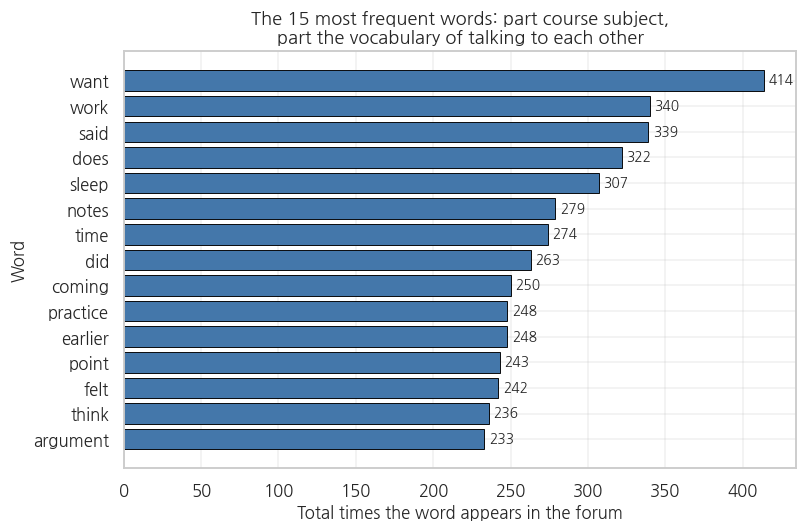

In [10]:
top15 = freq.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top15.index, top15.values, color='#4477AA', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Total times the word appears in the forum')
ax.set_ylabel('Word')
ax.set_title('The 15 most frequent words: part course subject,\npart the vocabulary of talking to each other')
for y, v in enumerate(top15.values):
    ax.text(v + 3, y, str(v), va='center', fontsize=9)
plt.show()

**🧠 Interpret this chart.** Two kinds of word are tangled together at the top of this list, and neither one answers your question.

Some are the vocabulary of the course subject: `sleep`, `notes`, `practice`. Useful for confirming you loaded the right file, useless for knowing what anybody thinks. The rest are the vocabulary of *talking*: `want`, `work`, `said`, `does`, `coming`, `earlier`, `point`, `think`, `argument`. Those are the most frequent words in the forum because forums are made of people addressing each other, and every week's discussion contains them equally.

Notice `coming` and `earlier` in particular. Those are the traces of students referring back to somebody else's post, and they will reappear in Section 6 as the `connecting` discourse move. Raw frequency has just put a genuinely interesting signal in front of you and given you no way to tell it apart from noise.

That is the standard limitation of raw frequency: it ranks, and ranking is not comparison. The next cell asks a better question: which words are unusually common in one week compared with the forum as a whole?

In [11]:
def distinctive_words(week, n=6, min_count=10):
    """Words whose share of one week most exceeds their share of the whole corpus."""
    rows = np.where((posts['week'] == week).values)[0]
    week_counts = np.asarray(X_counts[rows].sum(axis=0)).ravel()
    week_share = week_counts / week_counts.sum()
    overall_share = totals / totals.sum()
    ratio = np.where(week_counts >= min_count, week_share / overall_share, 0)
    idx = np.argsort(ratio)[::-1][:n]
    return ', '.join(vocab[idx])

distinct = pd.DataFrame({
    'week': list(WEEK_TOPICS),
    'actual topic': [WEEK_TOPICS[w] for w in WEEK_TOPICS],
    'most distinctive words': [distinctive_words(w) for w in WEEK_TOPICS],
})
print(distinct.to_string(index=False))

 week  actual topic                                                     most distinctive words
    1        memory                          partner, blank, attempt, false, facts, explaining
    2       spacing                   inefficient, interval, revisiting, topics, borrows, poor
    3 metacognition                  step, exactly, reflection, mistaken, predictions, follows
    4    motivation                  autonomy, difficult, harder, intervention, tells, matters
    5 collaboration fragments, disagreement, assigning, collaboration, facilitator, individual
    6   note taking                      reliably, shorter, mapping, unrelated, recorded, note
    7         sleep                           young, rough, weekend, wave, nights, obligations
    8  test anxiety                        racing, getting, component, heart, anxious, warning

**🧠 Interpret this table.** Read the third column and cover the second with your hand. Could you have recovered the week's topic from the words alone? For most weeks, yes, easily. Keep that experience in mind, because in Section 5 a topic model will hand you exactly this kind of list, and you will have to name the topics *without* the answer key sitting in the next column over. The confidence you feel right now is borrowed from the answer key.

---

## 📊 4. Sentiment from a lexicon you can read in full

Most sentiment tools arrive as a black box you install. We are not doing that, for two reasons. The practical one: downloads break, and a notebook that needs the network is a notebook that fails in a classroom. The real one: **you cannot critique a word list you have never seen.**

So here is the entire lexicon. Thirty-two positive words, thirty-four negative words, chosen by reading this corpus. It is written in the cell below in plain sight, you can edit it, and every number in this section comes from these two lists and nothing else.

Two details worth naming:

- We score on the **raw** text, lowercased but with stopwords intact, so that negation survives.
- We handle negation crudely: if `not`, `never`, `no`, `without`, or `hardly` appears in the three words before a sentiment word, we flip its sign. Crude is the honest word for it. "Not the most useful reading" gets handled; "I would not say this was anything other than useful" does not.
- We divide by post length, so a long post is not automatically more emotional than a short one.

In [12]:
POSITIVE_WORDS = """
useful helpful clear convinced surprised worked works helped better best strongest
good great glad excited confident improved productive value worth easier calm
right interesting compelling powerful gains success enjoy fair honest relief
""".split()

NEGATIVE_WORDS = """
frustrating discouraging hard difficult confusing stuck worried anxiety anxious
stress stressed fail failed worse bad skeptical doubt overwhelmed embarrassingly
panic blanked spiraling avoidance cramming debt lapses deprivation uncomfortable
slow useless waste tired exhausted guilty
""".split()

NEGATORS = {'not', 'never', 'no', 'without', 'hardly'}

POS_SET, NEG_SET = set(POSITIVE_WORDS), set(NEGATIVE_WORDS)
print('Lexicon size:', len(POS_SET), 'positive words,', len(NEG_SET), 'negative words')
print()
print('POSITIVE:', ', '.join(sorted(POS_SET)))
print()
print('NEGATIVE:', ', '.join(sorted(NEG_SET)))

Lexicon size: 32 positive words, 34 negative words

POSITIVE: best, better, calm, clear, compelling, confident, convinced, easier, enjoy, excited, fair, gains, glad, good, great, helped, helpful, honest, improved, interesting, powerful, productive, relief, right, strongest, success, surprised, useful, value, worked, works, worth

NEGATIVE: anxiety, anxious, avoidance, bad, blanked, confusing, cramming, debt, deprivation, difficult, discouraging, doubt, embarrassingly, exhausted, fail, failed, frustrating, guilty, hard, lapses, overwhelmed, panic, skeptical, slow, spiraling, stress, stressed, stuck, tired, uncomfortable, useless, waste, worried, worse


Now the scorer. Read it: it is fifteen lines and there is nothing hidden in it.

In [13]:
def lexicon_sentiment(text, pos_set=POS_SET, neg_set=NEG_SET):
    """Return (score per 100 words, n positive hits, n negative hits).

    A hit flips sign if a negator sits within the three preceding tokens.
    """
    tokens = re.sub(r"[^a-z\s']", ' ', text.lower()).split()
    pos = neg = 0
    for i, tok in enumerate(tokens):
        if tok in pos_set:
            value = 1
        elif tok in neg_set:
            value = -1
        else:
            continue
        window = tokens[max(0, i - 3):i]
        if any(w in NEGATORS for w in window):
            value = -value
        if value > 0:
            pos += 1
        else:
            neg += 1
    score = (pos - neg) / max(len(tokens), 1) * 100
    return score, pos, neg


scored = posts['text'].apply(lexicon_sentiment)
posts['sentiment'] = [s[0] for s in scored]
posts['n_pos'] = [s[1] for s in scored]
posts['n_neg'] = [s[2] for s in scored]

print('Sentiment score, per 100 words:')
print(posts['sentiment'].describe().round(2).to_string())
print()
print('Share of posts with no sentiment word at all:',
      f"{((posts['n_pos'] + posts['n_neg']) == 0).mean():.1%}")

Sentiment score, per 100 words:
count    1456.00
mean        0.70
std         2.24
min        -7.79
25%         0.00
50%         0.00
75%         2.05
max        12.90

Share of posts with no sentiment word at all: 19.2%


Let us look at the distribution and at the weekly averages together. The distribution tells you whether the measure has any spread at all (a sentiment score that is zero for everyone is not measuring anything). The weekly averages are what people usually report.

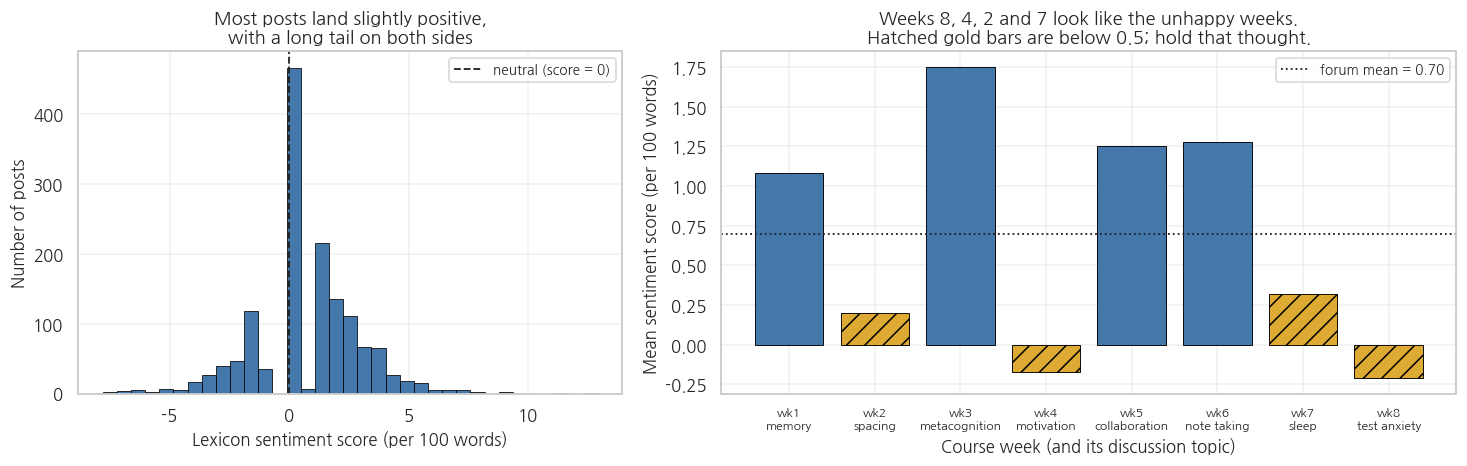

      mean   std  size          topic
week                                 
1     1.08  1.78   195         memory
2     0.20  1.74   189        spacing
3     1.75  2.76   177  metacognition
4    -0.17  2.18   165     motivation
5     1.25  1.65   174  collaboration
6     1.28  1.69   190    note taking
7     0.32  2.49   196          sleep
8    -0.21  2.57   170   test anxiety


In [14]:
week_sent = posts.groupby('week')['sentiment'].agg(['mean', 'std', 'size']).round(2)
week_sent['topic'] = week_sent.index.map(WEEK_TOPICS)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4),
                         gridspec_kw={'width_ratios': [1, 1.35]})

axes[0].hist(posts['sentiment'], bins=35, color='#4477AA', edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='#222222', linestyle='--', linewidth=1.2, label='neutral (score = 0)')
axes[0].set_xlabel('Lexicon sentiment score (per 100 words)')
axes[0].set_ylabel('Number of posts')
axes[0].set_title('Most posts land slightly positive,\nwith a long tail on both sides')
axes[0].legend(fontsize=9)

colors = ['#DDAA33' if v < 0.5 else '#4477AA' for v in week_sent['mean']]
hatches = ['//' if v < 0.5 else '' for v in week_sent['mean']]
bars = axes[1].bar(week_sent.index, week_sent['mean'], color=colors,
                   edgecolor='black', linewidth=0.6)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
axes[1].set_xticks(list(week_sent.index))
axes[1].set_xticklabels([f"wk{w}\n{WEEK_TOPICS[w]}" for w in week_sent.index], fontsize=8)
axes[1].set_xlabel('Course week (and its discussion topic)')
axes[1].set_ylabel('Mean sentiment score (per 100 words)')
axes[1].set_title('Weeks 8, 4, 2 and 7 look like the unhappy weeks.\nHatched gold bars are below 0.5; hold that thought.')
axes[1].axhline(posts['sentiment'].mean(), color='#222222', linestyle=':', linewidth=1.2,
                label=f"forum mean = {posts['sentiment'].mean():.2f}")
axes[1].legend(fontsize=9)
plt.show()

print(week_sent.to_string())

**🧠 Interpret this figure.** The lexicon says the forum is mildly positive overall (mean 0.70), and that week 8 (test anxiety, mean -0.21) and week 4 (motivation, -0.17) are the only two weeks that come out net *negative*, with week 2 (spacing, 0.20) and week 7 (sleep, 0.32) close behind. Week 3 (metacognition, 1.75) is the high point.

Notice the histogram too: the tallest bar sits exactly on zero, because 19 percent of posts contain no word from our lexicon at all. Every one of those posts is counted as perfectly neutral. They are not neutral. They are unmeasured, and the mean cannot tell the difference.

If you stopped here you would write: *"Student affect dipped into negative territory during the test anxiety unit."* It would be a sentence in a paper. It would have a bar chart under it. Now go check it against the posts.

This next cell is the whole point of the section. It prints, in full, the posts the lexicon scored as the most negative in the entire forum. Read them. Actually read them, do not skim.

In [15]:
print('=== THE FIVE MOST NEGATIVE POSTS ACCORDING TO OUR LEXICON ===\n')
for _, row in posts.nsmallest(5, 'sentiment').iterrows():
    hits = [t for t in re.sub(r"[^a-z\s']", ' ', row['text'].lower()).split() if t in NEG_SET]
    print(f"[{row['post_id']} | week {row['week']} ({row['topic_label']}) | "
          f"score {row['sentiment']:.2f} | negative words found: {hits}]")
    print(row['text'])
    print('-' * 100)

=== THE FIVE MOST NEGATIVE POSTS ACCORDING TO OUR LEXICON ===

[F1426 | week 8 (test anxiety) | score -7.79 | negative words found: ['anxiety', 'blanked', 'slow', 'spiraling', 'hard', 'skeptical']]
I read that section on expressive writing differently. Stated plainly, anxiety consumes the working memory the test is trying to measure. The first time I tried planning what I would do if I blanked on the first page it felt slow, but I stopped spiraling after the first hard question. I am holding this loosely, because the effects are much smaller outside psychology labs. I am skeptical, and I am open to being talked out of it.
----------------------------------------------------------------------------------------------------
[F1272 | week 7 (sleep) | score -7.69 | negative words found: ['debt', 'lapses']]
Coming back to an earlier comment on social jetlag. My takeaway is that sleep debt shows up as attention lapses long before it feels like fatigue.
----------------------------------------

**🧠 Interpret what you just read.** Look at the flagged words: `anxiety`, `blanked`, `spiraling`, `hard`, `debt`, `lapses`. Now look at what the posts are actually saying.

Two of the five (F1426 and F1424) describe a strategy that **worked**: "When I started planning what I would do if I blanked on the first page, I stopped spiraling after the first hard question." That is a student reporting success, scored as the most miserable text in the forum.

The other three come from week 7, and the entire negative signal in one of them (F1272) is two words: `debt` and `lapses`. The post is a neutral two-sentence summary of a finding about sleep. It scores second-lowest in a corpus of 1,456 posts because the technical vocabulary of sleep research happens to sound sad.

The lexicon is not measuring how students feel. On these posts it is measuring **what the week was about.** Week 8 was assigned to discuss test anxiety, so week 8 posts contain the word "anxiety" whether the writer is panicking or reporting that reappraisal fixed their panic.

This failure has a name in the literature: topic and sentiment are confounded when your lexicon contains topic vocabulary. It is not exotic. It is the most common way a sentiment analysis in education research goes quietly wrong, and it survives peer review regularly, because the bar chart looks fine.

### ✏️ Your turn 2: repair the lexicon and watch week 8 move

The fix is a design decision, and it is yours to make. `WORDS_TO_DROP` below removes the words that name a week's *subject matter* rather than a writer's *stance*. The list is already filled in with a working answer, so you can run it untouched, then argue with it.

Think before you run: which of these words are genuinely topic vocabulary here, and which are real evaluations that you would be wrong to delete? `hard` is a good one to fight about.

Negative lexicon:  34 words -> 22 words

      v1 (topic words in)  v2 (topic words out)  change          topic
week                                                                  
1                    1.08                  1.31    0.23         memory
2                    0.20                  0.72    0.52        spacing
3                    1.75                  1.98    0.23  metacognition
4                   -0.17                 -0.06    0.11     motivation
5                    1.25                  1.25    0.00  collaboration
6                    1.28                  1.28    0.00    note taking
7                    0.32                  1.54    1.22          sleep
8                   -0.21                  1.11    1.32   test anxiety


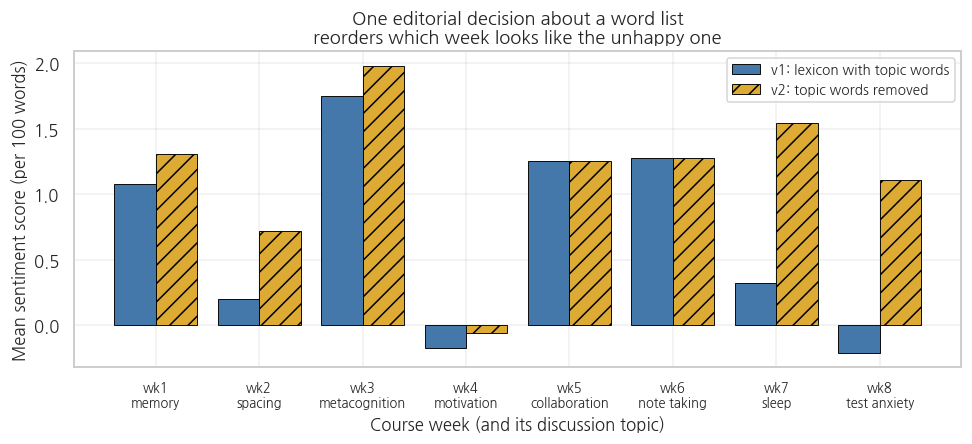

In [16]:
# TODO (optional): edit this list. Which of these words name the topic
# rather than the writer's stance? Add or remove and re-run.
WORDS_TO_DROP = ['anxiety', 'anxious', 'debt', 'lapses', 'deprivation', 'cramming',
                 'panic', 'blanked', 'spiraling', 'avoidance', 'stress', 'stressed']

NEG_SET_V2 = NEG_SET - set(WORDS_TO_DROP)
print('Negative lexicon: ', len(NEG_SET), 'words ->', len(NEG_SET_V2), 'words\n')

posts['sentiment_v2'] = posts['text'].apply(
    lambda t: lexicon_sentiment(t, POS_SET, NEG_SET_V2)[0])

compare = posts.groupby('week')[['sentiment', 'sentiment_v2']].mean().round(2)
compare.columns = ['v1 (topic words in)', 'v2 (topic words out)']
compare['change'] = (compare.iloc[:, 1] - compare.iloc[:, 0]).round(2)
compare['topic'] = compare.index.map(WEEK_TOPICS)
print(compare.to_string())

x = np.arange(len(compare))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - 0.2, compare.iloc[:, 0], width=0.4, label='v1: lexicon with topic words',
       color='#4477AA', edgecolor='black', linewidth=0.6)
ax.bar(x + 0.2, compare.iloc[:, 1], width=0.4, label='v2: topic words removed',
       color='#DDAA33', edgecolor='black', linewidth=0.6, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels([f"wk{w}\n{WEEK_TOPICS[w]}" for w in compare.index], fontsize=8.5)
ax.set_xlabel('Course week (and its discussion topic)')
ax.set_ylabel('Mean sentiment score (per 100 words)')
ax.set_title('One editorial decision about a word list\nreorders which week looks like the unhappy one')
ax.legend(fontsize=9)
plt.show()

**🧠 Interpret this comparison.** Week 8 moves the most, by 1.32 points: it goes from the most negative week in the forum (-0.21) to a comfortably positive one (1.11). Week 7 (sleep) climbs almost as far, 1.22 points, once `debt` and `lapses` stop counting as misery. Weeks 5 and 6 do not move at all, because their topic vocabulary was never in the list. Nothing about the students changed. A word list changed.

Now write the uncomfortable sentence in your memo: **which version is correct?** There is no purely technical answer. If your research question is "what did students find difficult," v1 may be closer, because a post full of anxiety vocabulary really is a post about difficulty. If your question is "how did students evaluate the readings," v2 is closer. The choice is a claim about what you are measuring, and it belongs in your methods section where a reader can disagree with it. A lexicon you did not write and cannot inspect makes that choice for you and does not tell you it did.

---

## 📊 5. Topic modeling: NMF and LDA, side by side

A topic model reads a pile of documents and proposes groups of words that tend to occur together. That is genuinely all it does. It does not know what a topic is, it cannot name anything, and it has never read a syllabus.

We will fit two of them on the same 1,456 posts:

- **NMF** (Non-negative Matrix Factorization) is linear algebra. It factors the document-term matrix into two non-negative matrices and reads topics off one of them. It usually pairs with **TF-IDF** weighting, which downweights words that appear everywhere.
- **LDA** (Latent Dirichlet Allocation) is a probabilistic model. It assumes each document is a mixture of topics and each topic is a distribution over words, then estimates both. It wants **raw counts**, not TF-IDF.

We ask both for 8 topics, because we happen to know the course ran 8 weekly topics. In your own research you will not know the number, and choosing it is a genuinely unsolved problem that people paper over with a fit statistic.

In [17]:
N_TOPICS = 8

# NMF wants TF-IDF weighting.
tfidf_vec = TfidfVectorizer(stop_words=sorted(MY_STOPWORDS), min_df=5, max_df=0.5)
X_tfidf = tfidf_vec.fit_transform(posts['clean'])
tfidf_vocab = np.array(tfidf_vec.get_feature_names_out())

nmf_model = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE,
                init='nndsvda', max_iter=600)
W_nmf = nmf_model.fit_transform(X_tfidf)

# LDA wants raw counts (we already built X_counts in Section 3).
lda_model = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                      max_iter=25, learning_method='batch')
W_lda = lda_model.fit_transform(X_counts)

print('NMF  document-topic matrix:', W_nmf.shape)
print('LDA  document-topic matrix:', W_lda.shape)
print('Both models fit. Neither one has any idea what a course is.')

NMF  document-topic matrix: (1456, 8)
LDA  document-topic matrix: (1456, 8)
Both models fit. Neither one has any idea what a course is.


Now the part everybody skips: printing the topics next to each other and staring at them. A topic is a ranked word list. Naming it is an act of interpretation performed by a human being, and that human being is you, and you are responsible for the name you choose.

In [18]:
def top_words(model, feature_names, n=10):
    return [', '.join(feature_names[c.argsort()[-n:][::-1]]) for c in model.components_]

nmf_words = top_words(nmf_model, tfidf_vocab)
lda_words = top_words(lda_model, vocab)

side_by_side = pd.DataFrame({
    'k': range(N_TOPICS),
    'NMF topic (top 10 words)': nmf_words,
    'LDA topic (top 10 words)': lda_words,
})
for _, r in side_by_side.iterrows():
    print(f"--- topic {r['k']} ---")
    print('  NMF:', r['NMF topic (top 10 words)'])
    print('  LDA:', r['LDA topic (top 10 words)'])

--- topic 0 ---
  NMF: test, stakes, anxiety, underprepared, practice, assessment, students, working, writing, real
  LDA: like, looks, work, self, motivation, cost, airtight, evidence, goals, course
--- topic 1 ---
  NMF: sleep, hour, studying, debt, study, lapses, attention, hours, strategy, circadian
  LDA: recall, retrieval, memory, effort, practice, does, forgetting, feels, dependent, did
--- topic 2 ---
  NMF: notes, note, structure, function, concept, encoding, questions, lecture, write, does
  LDA: sleep, earlier, want, push, piece, agree, study, hour, hours, worth
--- topic 3 ---
  NMF: group, shared, people, regulation, disagreement, idea, hide, turned, equal, friction
  LDA: notes, note, does, function, structure, encoding, questions, argument, lecture, concept
--- topic 4 ---
  NMF: spacing, review, scheduling, time, interleaving, long, practice, calendar, felt, schedule
  LDA: reflection, monitoring, confident, want, point, fluency, exactly, session, calibration, changes
-

**🧠 Interpret these word lists before you look at any chart.** Cover the rest of the notebook and try to name all sixteen topics from the words alone. Most are nameable: `notes, note, structure, function, concept, encoding` is clearly the note taking week in both models.

Two things are worth slowing down for.

First, **the model numbers mean nothing.** NMF topic 0 is the test anxiety week; LDA topic 0 is the motivation week. There is no correspondence between the numberings, and any you find is one you constructed by reading.

Second, look at LDA topic 2: `sleep, earlier, want, push, piece, agree, study, hour, hours, worth`. Half of that list is the sleep week and the other half (`earlier`, `want`, `push`, `piece`, `agree`) is the vocabulary of **arguing with somebody**. LDA has blended a subject with a discussion register in a single topic. NMF's sleep topic (`sleep, hour, studying, debt, study, lapses, attention, hours, strategy, circadian`) is pure subject matter. Neither model will tell you which of those is the better description of what week 7 was, and a coherence score will not either.

Now, because this is a teaching dataset, we have the answer key. Cross-tabulate each model's dominant topic against the week the post was actually written in.

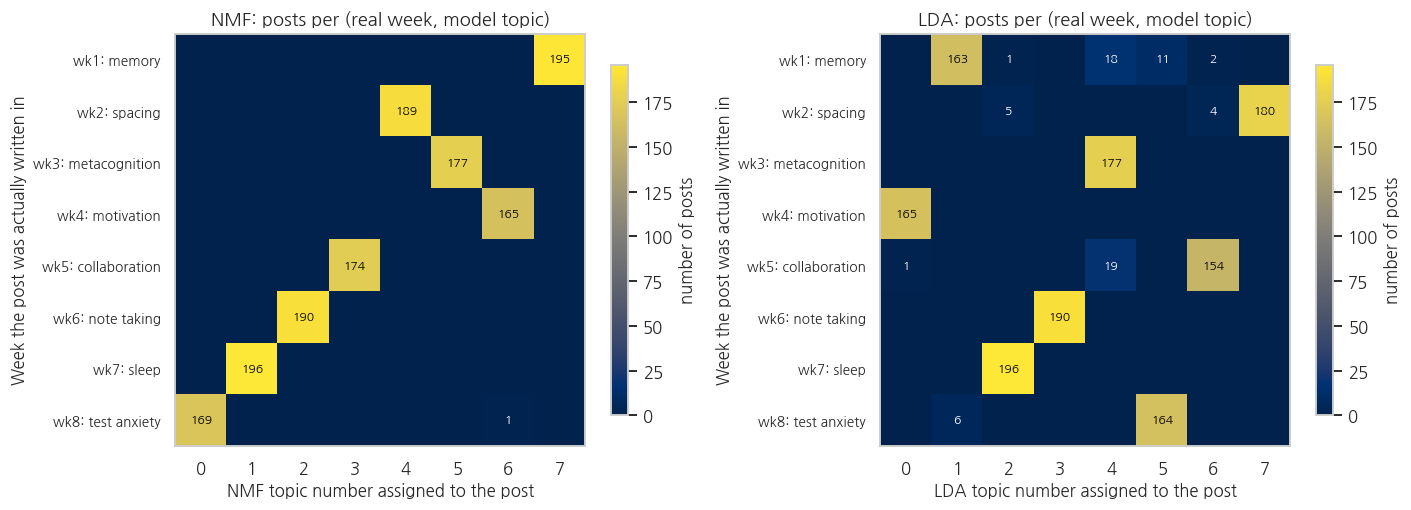

Agreement with the real weekly topics (adjusted Rand index, 1.0 = perfect):
  NMF vs actual week : 0.999
  LDA vs actual week : 0.9


  NMF vs LDA         : 0.899


In [19]:
posts['nmf_topic'] = W_nmf.argmax(axis=1)
posts['lda_topic'] = W_lda.argmax(axis=1)

ct_nmf = pd.crosstab(posts['week'], posts['nmf_topic'])
ct_lda = pd.crosstab(posts['week'], posts['lda_topic'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, ct, name in zip(axes, [ct_nmf, ct_lda], ['NMF', 'LDA']):
    im = ax.imshow(ct.values, cmap='cividis', aspect='auto')
    ax.set_xticks(range(ct.shape[1]))
    ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(ct.shape[0]))
    ax.set_yticklabels([f"wk{w}: {WEEK_TOPICS[w]}" for w in ct.index], fontsize=9)
    ax.set_xlabel(f'{name} topic number assigned to the post')
    ax.set_ylabel('Week the post was actually written in')
    ax.set_title(f'{name}: posts per (real week, model topic)')
    ax.grid(False)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            v = ct.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                        color='white' if v < ct.values.max() * 0.6 else 'black')
    fig.colorbar(im, ax=ax, label='number of posts', shrink=0.85)
plt.show()

print('Agreement with the real weekly topics (adjusted Rand index, 1.0 = perfect):')
print('  NMF vs actual week :', round(adjusted_rand_score(posts['week'], posts['nmf_topic']), 3))
print('  LDA vs actual week :', round(adjusted_rand_score(posts['week'], posts['lda_topic']), 3))
print('  NMF vs LDA         :', round(adjusted_rand_score(posts['nmf_topic'], posts['lda_topic']), 3))

**🧠 Interpret these two heatmaps.** Same corpus, same number of topics, same random seed. They do not tell the same story.

- **NMF** is a clean diagonal. Every week maps onto exactly one topic and precisely **one post out of 1,456** lands anywhere else. Adjusted Rand index against the real weeks: 0.999.
- **LDA** is diagonal-ish and leaky. Adjusted Rand index 0.900, and the leak is not random. **67 posts** land in a topic dominated by a different week, and 32 of them come from week 1 (memory) alone. Week 1's posts scatter into the metacognition topic (18), the test anxiety topic (11), and the collaboration topic (2). Meanwhile LDA topic 4 is a genuine blend: 177 metacognition posts, 19 collaboration posts, and 18 memory posts sharing one topic.

The two models agree with each other at 0.899, which is another way of saying they disagree about roughly one post in twenty. Twenty is not many when the thing you are going to write is "the forum had eight distinct topics."

Two honest readings are available and you have to pick one.

*Reading A: NMF is right and LDA is leaking.* We have ground truth here. NMF recovered it almost exactly, LDA did not, and those 67 posts are simply errors. If you need topic labels to build anything downstream, use the model that gets them right.

*Reading B: LDA found something real.* Memory, metacognition, and note taking are not separable subjects. A post about turning section headings into questions is about memory and metacognition and study strategy at once, because that is how learning strategies work. LDA is a mixture model, so it can say a document is 60 percent one thing and 40 percent another, and our `argmax` step threw that nuance away before we ever plotted it. The weekly labels are an administrative fact about when a post was due, not a claim that the ideas are disjoint. Notice also *which* week leaks: memory, the first week, whose vocabulary the rest of the semester keeps borrowing.

Reading B is not a consolation prize. It is the reason a leaky topic model is sometimes more faithful to the discourse than a clean one. What Reading B costs you is the tidy sentence, and tidy sentences are what get quoted.

**In your memo, pick A or B and defend it with specific posts.** The next cell gets you the posts.

In [20]:
# Find the LDA topic that blends the most weeks, and read what landed in it.
mix = pd.crosstab(posts['lda_topic'], posts['week'])
spread = (mix >= 10).sum(axis=1).sort_values(ascending=False)
messy_topic = int(spread.index[0])
counts = mix.loc[messy_topic][mix.loc[messy_topic] > 0]

print(f'LDA topic {messy_topic} draws 10 or more posts from '
      f'{spread.iloc[0]} different weeks.\n')
print('Posts in that topic, by the week they were actually written in:')
for w, n in counts.items():
    print(f'   week {w} ({WEEK_TOPICS[w]:14s}): {n}')
print()
print('Top words of that LDA topic:', lda_words[messy_topic])
print()

dominant = int(counts.idxmax())
guests = [w for w in counts.index if w != dominant]
print(f'=== POSTS FROM OTHER WEEKS THAT LDA FILED WITH '
      f'{WEEK_TOPICS[dominant].upper()} ===\n')
for w in guests:
    r = posts[(posts['lda_topic'] == messy_topic) & (posts['week'] == w)].iloc[0]
    print(f"[{r['post_id']} | actually week {r['week']} ({r['topic_label']}) | "
          f"NMF topic {r['nmf_topic']} | LDA topic {r['lda_topic']}]")
    print(r['text'])
    print('-' * 100)

LDA topic 4 draws 10 or more posts from 3 different weeks.

Posts in that topic, by the week they were actually written in:
   week 1 (memory        ): 18
   week 3 (metacognition ): 177
   week 5 (collaboration ): 19

Top words of that LDA topic: reflection, monitoring, confident, want, point, fluency, exactly, session, calibration, changes

=== POSTS FROM OTHER WEEKS THAT LDA FILED WITH METACOGNITION ===

[F0015 | actually week 1 (memory) | NMF topic 7 | LDA topic 4]
Adding a small counterexample to what has been said about cue dependent forgetting. The reading argues that how we encode something decides what cues will bring it back later, and I think that is right. When I started quizzing myself on the vocabulary instead of highlighting it, it took longer but it stuck for the whole week. It is worth remembering that we never see how long the advantage lasts past a semester.
----------------------------------------------------------------------------------------------------
[F0732 | 

**🧠 Interpret these posts.** LDA put both of them in the metacognition topic. NMF put them in the memory topic and the collaboration topic respectively, matching the weeks they were written in.

Read F0015 (week 1, memory). It says: "When I started quizzing myself on the vocabulary instead of highlighting it, it took longer but it stuck for the whole week. It is worth remembering that we never see how long the advantage lasts past a semester." That is a student monitoring their own strategy and qualifying their own evidence. Is that a memory post or a metacognition post? The syllabus says memory. The student is doing metacognition.

Now read F0732 (week 5, collaboration): a report on trying a planning routine and watching what happened. Same structure.

So ask the only question that matters: is LDA wrong to file these together, or is it noticing a similarity that the weekly calendar hides? Whatever you decide, that decision is now yours and you own it. Neither model can be blamed for it, because neither model made it.

One more honest note before we leave this section. We only know NMF "won" because this is a teaching corpus with a planted structure. In your course research project you will have no answer key, no heatmap like this, and no way to compute an adjusted Rand index. You will have two word lists and your own judgment. Practicing that judgment here, where you can check yourself, is the entire purpose of using synthetic data.

### ✏️ Your turn 3: ask for the wrong number of topics

`N_TOPICS = 8` was not discovered, it was assumed, because we knew the course had 8 weekly topics. Change `N_TOPICS_TRY` below and see what a model does when you ask it for a number the data does not have. It runs with 4 as written.

Watch for what happens: the model will always give you exactly the number of topics you ask for. It will never tell you the number was wrong. This is worth feeling in your hands once.

In [21]:
# TODO (optional): try 4, then 12, then 20. What happens to the word lists?
N_TOPICS_TRY = 4

trial = NMF(n_components=N_TOPICS_TRY, random_state=RANDOM_STATE,
            init='nndsvda', max_iter=600).fit(X_tfidf)

print(f'NMF with {N_TOPICS_TRY} topics:\n')
for i, words in enumerate(top_words(trial, tfidf_vocab, n=8)):
    print(f'  topic {i}: {words}')

trial_assign = trial.transform(X_tfidf).argmax(axis=1)
print()
print('Weeks folded into each topic (count of posts):')
print(pd.crosstab(posts['week'], trial_assign).to_string())
print()
print('Adjusted Rand index against real weeks:',
      round(adjusted_rand_score(posts['week'], trial_assign), 3))

NMF with 4 topics:

  topic 0: practice, spacing, test, want, felt, did, time, memory
  topic 1: sleep, hour, studying, debt, study, hours, lapses, attention
  topic 2: notes, note, structure, function, encoding, concept, questions, lecture
  topic 3: group, shared, people, regulation, idea, disagreement, hide, turned

Weeks folded into each topic (count of posts):
col_0    0    1    2    3
week                     
1      194    0    0    1
2      189    0    0    0
3      169    2    0    6
4      165    0    0    0
5        0    0    0  174
6        0    0  190    0
7        0  196    0    0
8      170    0    0    0

Adjusted Rand index against real weeks: 0.321


---

## 📊 6. Discourse moves from rules you can argue with

Topic models tell you *what* a forum is about. They say nothing about what people are *doing* to each other in it, and in a discussion forum that is the whole pedagogical question. A thread where 200 people each post an unrelated opinion and a thread where 200 people build on each other look identical to a topic model.

So we tag five **discourse moves**, using regular expressions. Not machine learning: a list of patterns, written by a human, that anyone can read and disagree with. That transparency is a feature. When a rule is wrong you can see exactly why, which is rarely true of a classifier.

| Move | What we are trying to capture |
|---|---|
| `question` | asking the group something |
| `agreement` | endorsing or aligning with a previous contribution |
| `counterpoint` | qualifying, objecting, or pushing back |
| `evidence` | invoking the reading, a study, or data |
| `connecting` | linking to another person's post or to a previous week |

We tag on the **raw** text, not the cleaned column, for the reason we established in Section 2. A post can carry several moves at once, or none, and that is realistic.

In [22]:
DISCOURSE_RULES = {
    'question': [
        r'\?',
    ],
    'agreement': [
        r'\bagree\b', r'convinced me', r'\bmakes sense\b', r'\bgood point\b',
        r'\bexactly\b', r'\bresonat', r'\byes\b', r'\bthis matches\b',
    ],
    'counterpoint': [
        r'\bbut\b', r'\bhowever\b', r'\bskeptic', r'\bpush back\b', r'\bdisagree\b',
        r'where i get stuck', r'\bthe caveat\b', r'\bnot sure\b', r'\balthough\b',
        r'\bholding this loosely\b', r'\bon the other hand\b', r'\binstead\b',
        r'\bdifferently\b',
    ],
    'evidence': [
        r'\bthe authors\b', r'\bthe reading\b', r'\bthe study\b', r'\bthe chapter\b',
        r'\bthe paper\b', r'\bthe article\b', r'\bresearch\b', r'\bstudies\b',
        r'\bthe data\b', r'\bthe finding', r'\bthe claim\b', r'\bthe argument\b',
    ],
    'connecting': [
        r'\bbuilding on\b', r'\bearlier\b', r'\blast week\b', r'\badding to\b',
        r'\bcoming back to\b', r'\bpicking up\b', r'\bsomeone\b', r'\bthe post above\b',
    ],
}

MOVES = list(DISCOURSE_RULES)
lower_text = posts['text'].str.lower()
for move, patterns in DISCOURSE_RULES.items():
    posts[move] = lower_text.str.contains('|'.join(patterns), regex=True).astype(int)

posts['n_moves'] = posts[MOVES].sum(axis=1)

print('Share of posts carrying each move:')
print((posts[MOVES].mean() * 100).round(1).to_string(), '\n(percent of 1,456 posts)')
print()
print('How many moves per post:')
print(posts['n_moves'].value_counts().sort_index().to_string())

Share of posts carrying each move:
question        55.2
agreement       23.8
counterpoint    48.5
evidence        58.1
connecting      37.5 
(percent of 1,456 posts)

How many moves per post:
n_moves
0     53
1    303
2    555
3    370
4    149
5     26


Plot the rates, and plot how many moves a single post carries, because "does anybody do more than one thing at a time" is a real question about discussion quality.

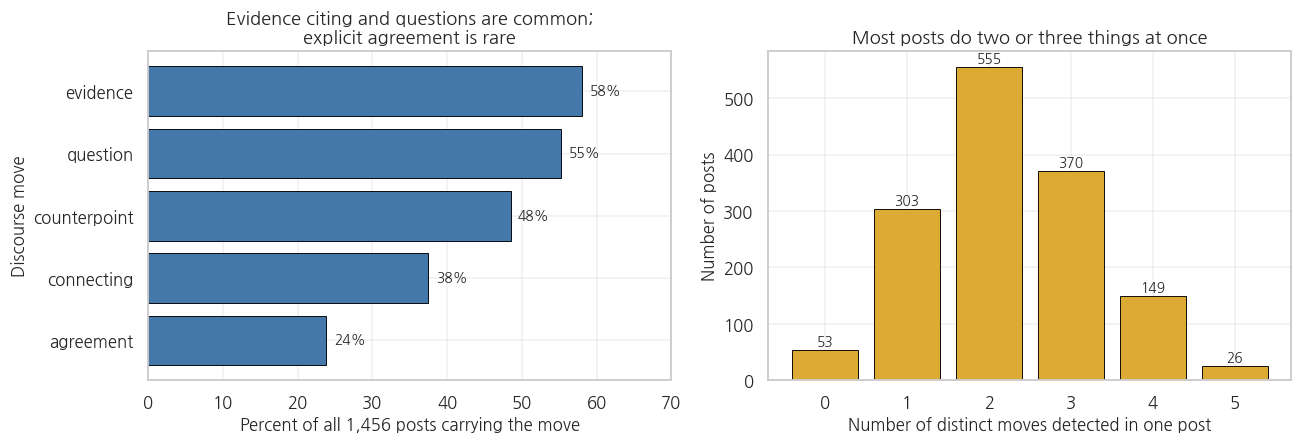

In [23]:
rates = (posts[MOVES].mean() * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].barh(rates.index, rates.values, color='#4477AA', edgecolor='black', linewidth=0.6)
axes[0].set_xlabel('Percent of all 1,456 posts carrying the move')
axes[0].set_ylabel('Discourse move')
axes[0].set_title('Evidence citing and questions are common;\nexplicit agreement is rare')
axes[0].set_xlim(0, 70)
for y, v in enumerate(rates.values):
    axes[0].text(v + 1, y, f'{v:.0f}%', va='center', fontsize=9)

counts = posts['n_moves'].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color='#DDAA33', edgecolor='black', linewidth=0.6)
axes[1].set_xlabel('Number of distinct moves detected in one post')
axes[1].set_ylabel('Number of posts')
axes[1].set_title('Most posts do two or three things at once')
axes[1].set_xticks(list(counts.index))
for x, v in zip(counts.index, counts.values):
    axes[1].text(x, v + 8, str(v), ha='center', fontsize=9)
plt.show()

**🧠 Interpret this figure.** Roughly 58 percent of posts cite evidence and 55 percent ask a question, while only 24 percent express explicit agreement. Before you write "students rarely agreed with one another," consider a duller explanation: our `agreement` pattern list has 8 patterns and our `counterpoint` list has 13. **We looked harder for disagreement than for agreement.** Rule-based measures are shaped by how much effort you put into each category, and effort is invisible in the output.

Fifty-three posts got zero moves. Those are not silent posts. They are posts our rules cannot see, which is a different thing, and if you reported "53 posts contained no discursive activity" you would have reported a fact about your regular expressions.

Now the step that separates a measurement from a guess: **check the rule against the posts by hand.**

We will audit the weakest pattern on purpose rather than sampling at random. Of the 13 patterns in `counterpoint`, one is doing far more work than the rest: the bare word `but`. The cell below finds every post where `but` was the *only* pattern that fired, and prints six of them. Read each one and decide whether it is really a counterpoint, meaning a qualification or a push against somebody's claim, or whether the word just happened to appear.

Auditing your weakest rule instead of a random sample is a defensible design and you must report that you did it, because it makes the precision you measure a **lower bound** on the rule as a whole rather than an estimate of it.

In [24]:
counter_patterns = DISCOURSE_RULES['counterpoint']
fired_patterns = lower_text.apply(
    lambda t: [p for p in counter_patterns if re.search(p, t)])

only_but = posts[fired_patterns.apply(lambda f: f == [r'\bbut\b'])]
print(f'Posts where the bare word "but" was the ONLY counterpoint pattern to fire: '
      f'{len(only_but)} of the {int(posts["counterpoint"].sum())} flagged posts\n')

sample = only_but.sample(6, random_state=1)
print('=== HAND-CODE THESE SIX. Is each really a counterpoint? ===\n')
for i, (_, r) in enumerate(sample.iterrows(), start=1):
    print(f"({i}) [{r['post_id']} | week {r['week']} ({r['topic_label']})]")
    print('   ', r['text'])
    print()

Posts where the bare word "but" was the ONLY counterpoint pattern to fire: 210 of the 706 flagged posts

=== HAND-CODE THESE SIX. Is each really a counterpoint? ===

(1) [F0300 | week 2 (spacing)]
    This thread is helping me see desirable difficulty more clearly. My takeaway is that cramming buys performance today and borrows it from next month. The first time I tried keeping a running list of topics due for another pass it felt slow, but my week stopped ending in panic. How far apart do your review sessions actually end up being?

(2) [F1380 | week 8 (test anxiety)]
    This framing of practice testing under pressure lines up with my own experience. What I did not expect was the claim that anxiety consumes the working memory the test is trying to measure. I gave arriving early enough to stop rushing an honest try, and it helped less than I hoped but it did help. Would you design a course around practice testing under pressure?

(3) [F0336 | week 2 (spacing)]
    I agree with the ear

**🧠 Interpret what you just read.** These six split cleanly into two kinds, and the rule cannot tell them apart.

Three of them (2, 4, 6 in the printout) open with "I agree with the earlier point about X, **but** I want to push on one piece." That is a textbook counterpoint: it names a prior claim and qualifies it. The rule is right.

The other three (1, 3, 5) contain sentences like "The first time I tried keeping a running list of topics it felt **slow, but** my week stopped ending in panic" and "it helped less than I hoped **but** it did help." Those are within-sentence contrasts about the writer's own experiment. Nobody is being disagreed with. In fact post 1 opens "This thread is helping me see desirable difficulty more clearly," which is closer to agreement than to objection. The rule is catching English grammar, not argument.

That is precision, and it is measurable. The next cell lets you record your own judgments.

### ✏️ Your turn 4: measure how wrong the rule is, then fix it

Two small jobs.

First, hand-code the six posts above: put `1` if it really is a counterpoint and `0` if the rule misfired. The defaults below are the instructor's own coding, so the cell runs as is, but yours may differ, and disagreement between two coders about what counts is a finding, not a nuisance. That disagreement is exactly what an inter-rater reliability statistic exists to quantify. Then the cell corrects the headline counterpoint rate using your precision, which is a small but real piece of measurement work.

Second, `MY_RULES` adds a sixth move of your own. It ships with a working `hedging` category (the language of holding a claim loosely, which is arguably the most scholarly move in the list). Change it if you want to chase something else.

In [25]:
# TODO 1: replace with your own judgments, one per post, in the order printed above.
MY_CODES = [0, 0, 1, 1, 0, 1]

precision = float(np.mean(MY_CODES))
n_flagged = int(posts['counterpoint'].sum())
n_only_but = len(only_but)
n_other = n_flagged - n_only_but

print(f'Precision on the "but"-only posts: {precision:.0%} '
      f'({sum(MY_CODES)} of {len(MY_CODES)} were real counterpoints).')
print()
print('Correcting the headline number, treating the other patterns as sound:')
print(f'   flagged by some stronger pattern : {n_other} posts, assumed correct')
print(f'   flagged by bare "but" only       : {n_only_but} posts, about '
      f'{precision:.0%} correct')
corrected = (n_other + n_only_but * precision) / len(posts)
print(f'   rule says                        : {posts["counterpoint"].mean():.0%} '
      f'of posts carry a counterpoint')
print(f'   corrected estimate               : {corrected:.0%}')
print()
print('Caveats to carry into the memo: six posts is a tiny sample, and we audited')
print('the weakest pattern on purpose, so this is a floor and not an estimate.')
print()

# TODO 2: your own move. Add patterns, or invent a different category entirely.
MY_RULES = {
    'hedging': [r'\bholding this loosely\b', r'\bi am not certain\b', r'\bit depends\b',
                r'\bmight be\b', r'\bseems to\b', r'\bi would want to know more\b',
                r'\bbefore generalizing\b', r'\bsmall sample\b'],
}

for move, patterns in MY_RULES.items():
    posts[move] = lower_text.str.contains('|'.join(patterns), regex=True).astype(int)
    print(f"'{move}' fires on {posts[move].mean():.1%} of posts "
          f"({posts[move].sum()} posts).")
    hit = posts[posts[move] == 1]
    if len(hit):
        print('  example:', hit.iloc[0]['text'][:220], '...')

Precision on the "but"-only posts: 50% (3 of 6 were real counterpoints).

Correcting the headline number, treating the other patterns as sound:
   flagged by some stronger pattern : 496 posts, assumed correct
   flagged by bare "but" only       : 210 posts, about 50% correct
   rule says                        : 48% of posts carry a counterpoint
   corrected estimate               : 41%

Caveats to carry into the memo: six posts is a tiny sample, and we audited
the weakest pattern on purpose, so this is a floor and not an estimate.

'hedging' fires on 12.6% of posts (184 posts).
  example: Thank you for naming what bothered me about the forgetting curve. The strongest version of the argument is that how we encode something decides what cues will bring it back later. My hesitation is that the effect might b ...


---

## 📊 7. Where the methods disagree, and what you are going to do about it

You now have three independent readings of the same 1,456 posts:

1. a **sentiment** score from a word list you can see,
2. a **topic** assignment from two models that do not agree with each other,
3. a **discourse move** profile from rules you have already caught misfiring.

If all three pointed the same way, this section would be a formality. They do not. Put them in one table, by NMF topic, and look for the rows where they contradict each other.

In [26]:
nmf_names = {i: w.split(', ')[0] + ', ' + w.split(', ')[1] for i, w in enumerate(nmf_words)}

summary = posts.groupby('nmf_topic').agg(
    posts=('post_id', 'size'),
    sentiment=('sentiment', 'mean'),
    question=('question', 'mean'),
    agreement=('agreement', 'mean'),
    counterpoint=('counterpoint', 'mean'),
    evidence=('evidence', 'mean'),
    connecting=('connecting', 'mean'),
).round(3)
summary.insert(1, 'top NMF words', [nmf_names[i] for i in summary.index])
summary.insert(2, 'dominant real week',
               [WEEK_TOPICS[posts[posts['nmf_topic'] == i]['week'].mode()[0]] for i in summary.index])
for c in ['question', 'agreement', 'counterpoint', 'evidence', 'connecting']:
    summary[c] = (summary[c] * 100).round(0).astype(int)

print('Three methods, one table (move columns are percent of posts in that topic):')
print(summary.to_string())

Three methods, one table (move columns are percent of posts in that topic):
           posts          top NMF words dominant real week  sentiment  question  agreement  counterpoint  evidence  connecting
nmf_topic                                                                                                                     
0            169           test, stakes       test anxiety     -0.220        57         21            49        54          25
1            196            sleep, hour              sleep      0.322        58         23            50        59          50
2            190            notes, note        note taking      1.277        54         20            34        73          34
3            174          group, shared      collaboration      1.247        59         22            48        47          48
4            189        spacing, review            spacing      0.202        56         20            58        56          35
5            177  reflection, confi

Now put the two most quotable columns on one plot: mean sentiment against how often students pushed back. If the lexicon were measuring stance, negative topics should be the argumentative ones.

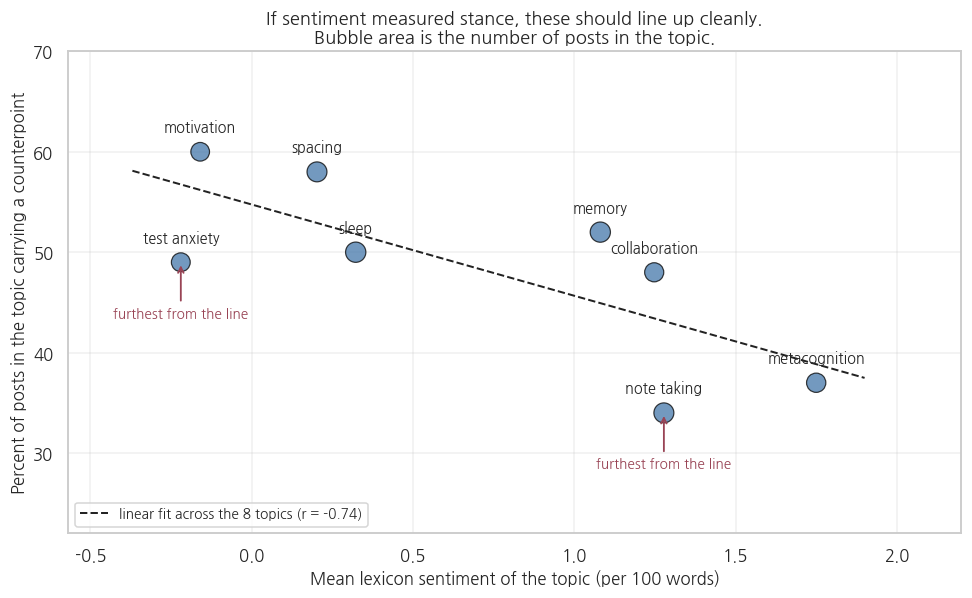

Correlation across the 8 topics between mean sentiment and counterpoint rate: r = -0.74

How far each topic sits from the line (positive = more pushback than its sentiment predicts):
                   top NMF words dominant real week  posts  sentiment  counterpoint  agreement  predicted cp  residual
nmf_topic                                                                                                             
2                    notes, note        note taking    190      1.277            34         20          43.1      -9.1
0                   test, stakes       test anxiety    169     -0.220            49         21          56.7      -7.7
7              recall, retrieval             memory    195      1.080            52         23          44.9       7.1
4                spacing, review            spacing    189      0.202            58         20          52.9       5.1
3                  group, shared      collaboration    174      1.247            48         22         

In [27]:
fig, ax = plt.subplots(figsize=(9, 5.6))

x = summary['sentiment'].values
y = summary['counterpoint'].values
r = np.corrcoef(x, y)[0, 1]

ax.scatter(x, y, s=summary['posts'] * 0.9, color='#4477AA', alpha=0.75,
           edgecolor='black', linewidth=0.8, zorder=3)

for xi, yi, lab in zip(x, y, summary['dominant real week']):
    ax.annotate(lab, (xi, yi), textcoords='offset points', xytext=(0, 13),
                ha='center', fontsize=9.5)

fit = np.poly1d(np.polyfit(x, y, 1))
grid = np.linspace(x.min() - 0.15, x.max() + 0.15, 50)
ax.plot(grid, fit(grid), color='#222222', linestyle='--', linewidth=1.3, zorder=2,
        label=f'linear fit across the 8 topics (r = {r:.2f})')

residual = y - fit(x)
outliers = np.argsort(np.abs(residual))[::-1][:2]
for i in outliers:
    ax.annotate('furthest from the line', (x[i], y[i]),
                textcoords='offset points', xytext=(0, -36),
                ha='center', fontsize=9, style='italic', color='#994455',
                arrowprops=dict(arrowstyle='->', color='#994455', linewidth=1.2))

ax.set_xlabel('Mean lexicon sentiment of the topic (per 100 words)')
ax.set_ylabel('Percent of posts in the topic carrying a counterpoint')
ax.set_title('If sentiment measured stance, these should line up cleanly.\n'
             'Bubble area is the number of posts in the topic.')
ax.set_xlim(x.min() - 0.35, x.max() + 0.45)
ax.set_ylim(y.min() - 12, y.max() + 10)
ax.legend(fontsize=9, loc='lower left')
plt.show()

print(f'Correlation across the 8 topics between mean sentiment and counterpoint rate: r = {r:.2f}')
print()
resid_table = summary[['top NMF words', 'dominant real week', 'posts',
                       'sentiment', 'counterpoint', 'agreement']].copy()
resid_table['predicted cp'] = fit(x).round(1)
resid_table['residual'] = residual.round(1)
print('How far each topic sits from the line (positive = more pushback than its '
      'sentiment predicts):')
print(resid_table.reindex(np.argsort(np.abs(residual))[::-1]).to_string())

**🧠 Interpret this figure carefully. This is the heart of the mini project.**

The overall slope is clearly negative, r = -0.74, which is the story you would expect: topics whose vocabulary the lexicon calls positive carry less pushback. If that held everywhere you could treat the two measures as interchangeable and report whichever was easier to explain. It does not hold everywhere.

- **Test anxiety** is the most negative topic in the forum (sentiment -0.22, the only one the lexicon puts below zero along with motivation), yet its counterpoint rate is 49 percent, nearly 8 points *below* what the line predicts for a topic that negative, and its agreement rate (21 percent) is ordinary. If students were genuinely upset about this material we would expect them to be arguing with it. They are not. They are agreeing and citing evidence at normal rates, in vocabulary that our word list scores as misery. Section 4 already told us why: the negativity is the subject matter, not the stance.
- **Note taking** sits 9 points below the line in the other direction: high sentiment (1.28) *and* the lowest counterpoint rate in the forum (34 percent), plus by far the highest evidence citing (73 percent). Agreeable, well sourced, and nobody arguing. Is that a well run week or a week where nothing was at stake?
- **Memory** is the third one to look at, 7 points *above* the line: one of the more positive topics (1.08) and simultaneously one of the most argumentative (52 percent counterpoint). Positive vocabulary and heavy pushback are supposed to be opposites.

So: **which reading do you trust?**

- *If you trust the sentiment measure*, week 8 was the hard week and the forum needs support during the test anxiety unit. That claim is cheap to make, easy to visualize, and could send an instructor to intervene on students who were, as far as the discourse moves can tell, doing fine.
- *If you trust the discourse moves*, the memory and motivation weeks were the intellectually liveliest, note taking was the quietest, and the test anxiety week was ordinary. That claim is harder to sell and rests on rules whose precision you measured at around 50 percent on their weakest pattern in Section 6.
- *If you trust neither*, say what you would need instead. Hand-coding a stratified sample of 100 posts? A sentiment lexicon validated on educational discourse rather than on product reviews? Asking the students?

**Every one of those three answers is defensible, and picking none of them is not.** Your memo has to pick one and argue it against the other two using specific posts and specific numbers from this notebook. Learning analytics work is full of moments exactly like this, and the difference between a good analyst and a bad one is not the pipeline. It is what they do standing right here.

In [28]:
# One last piece of evidence for your memo: posts the methods flatly contradict.
low_cut = posts['sentiment'].quantile(0.10)
contradictions = posts[(posts['sentiment'] <= low_cut) &
                       (posts['agreement'] == 1) &
                       (posts['counterpoint'] == 0)]

print(f'Posts in the most negative 10 percent by lexicon score '
      f'(score <= {low_cut:.2f}) that our rules read as AGREEMENT with no pushback: '
      f'{len(contradictions)}\n')
for _, r in contradictions.head(3).iterrows():
    print(f"[{r['post_id']} | week {r['week']} ({r['topic_label']}) | "
          f"sentiment {r['sentiment']:.2f} | agreement=1, counterpoint=0]")
    print(r['text'])
    print('-' * 100)

Posts in the most negative 10 percent by lexicon score (score <= -1.94) that our rules read as AGREEMENT with no pushback: 3

[F0391 | week 3 (metacognition) | sentiment -2.22 | agreement=1, counterpoint=0]
If I followed the chapter, we are confident about exactly the things we have not learned. During the statistics unit I ended up writing one sentence about what confused me at the end of each session, and the log made my avoidance patterns embarrassingly visible.
----------------------------------------------------------------------------------------------------
[F1118 | week 7 (sleep) | sentiment -3.03 | agreement=1, counterpoint=0]
Yes to all of this, and I want to add one thing about sleep debt. The authors seem to be saying that an early class schedule fights the circadian rhythm of most undergraduates.
----------------------------------------------------------------------------------------------------
[F1250 | week 7 (sleep) | sentiment -6.12 | agreement=1, counterpoint=0]
Yes t

**🧠 Interpret these posts.** These are individual documents where the two methods point in opposite directions on the same words. Quote at least one of them in your memo, by post id, and say which method you believe about *that specific post* and why. General statements about method limitations are easy to write and worth very little. A specific claim about post F1118 is checkable, and checkable is the standard.

---

## 📊 8. Stretch: compare the discourse of two different weeks

*(This section is the stretch goal. The core deliverable is complete without it. Attempt it if you have time or if you want a stronger analysis section in your memo.)*

Aggregate rates across all eight weeks hide the thing an instructor would most want to know: did the character of the conversation change from week to week? Same forum, same students, different topic and different point in the semester.

### ✏️ Your turn 5: pick the two weeks

`WEEK_A` and `WEEK_B` default to 3 (metacognition) and 6 (note taking), which is a comparison with something in it. Any two of 1 through 8 will run.

Percent of posts carrying each move:
              wk3: metacognition  wk6: note taking  difference
question                    55.4              53.7        -1.7
agreement                   44.1              19.5       -24.6
counterpoint                37.3              33.7        -3.6
evidence                    58.8              73.2        14.4
connecting                  39.5              34.2        -5.3

Posts compared: 177 in week 3, 190 in week 6
Mean sentiment: wk3 = 1.75, wk6 = 1.28


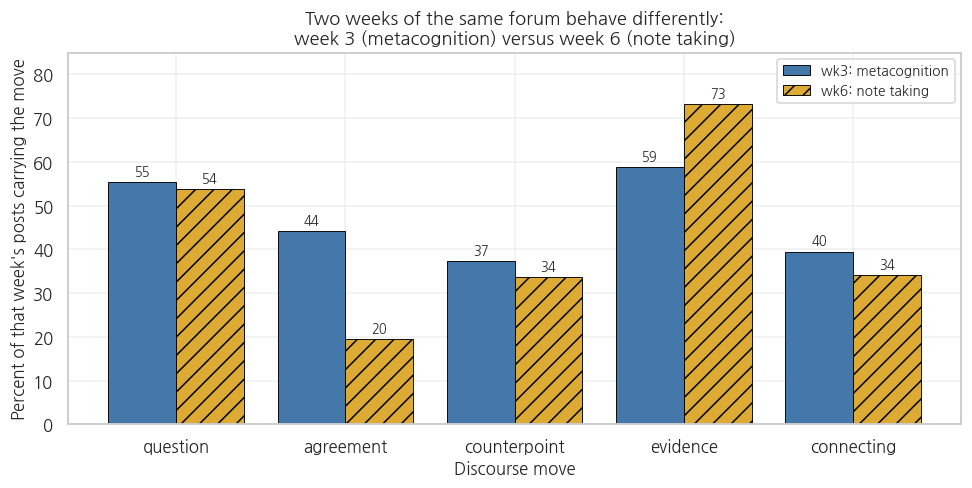

In [29]:
# TODO (optional): change these to any two weeks from 1 to 8.
WEEK_A = 3
WEEK_B = 6

a = posts[posts['week'] == WEEK_A]
b = posts[posts['week'] == WEEK_B]

comp = pd.DataFrame({
    f'wk{WEEK_A}: {WEEK_TOPICS[WEEK_A]}': (a[MOVES].mean() * 100).round(1),
    f'wk{WEEK_B}: {WEEK_TOPICS[WEEK_B]}': (b[MOVES].mean() * 100).round(1),
})
comp['difference'] = (comp.iloc[:, 1] - comp.iloc[:, 0]).round(1)
print('Percent of posts carrying each move:')
print(comp.to_string())
print()
print(f'Posts compared: {len(a)} in week {WEEK_A}, {len(b)} in week {WEEK_B}')
print(f"Mean sentiment: wk{WEEK_A} = {a['sentiment'].mean():.2f}, "
      f"wk{WEEK_B} = {b['sentiment'].mean():.2f}")

xs = np.arange(len(MOVES))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(xs - 0.2, comp.iloc[:, 0], width=0.4, color='#4477AA', edgecolor='black',
       linewidth=0.6, label=comp.columns[0])
ax.bar(xs + 0.2, comp.iloc[:, 1], width=0.4, color='#DDAA33', edgecolor='black',
       linewidth=0.6, hatch='//', label=comp.columns[1])
ax.set_xticks(xs)
ax.set_xticklabels(MOVES)
ax.set_xlabel('Discourse move')
ax.set_ylabel('Percent of that week\'s posts carrying the move')
ax.set_title(f'Two weeks of the same forum behave differently:\n'
             f'week {WEEK_A} ({WEEK_TOPICS[WEEK_A]}) versus week {WEEK_B} ({WEEK_TOPICS[WEEK_B]})')
ax.set_ylim(0, 85)
ax.legend(fontsize=9)
for xi, va, vb in zip(xs, comp.iloc[:, 0], comp.iloc[:, 1]):
    ax.text(xi - 0.2, va + 1.5, f'{va:.0f}', ha='center', fontsize=8.5)
    ax.text(xi + 0.2, vb + 1.5, f'{vb:.0f}', ha='center', fontsize=8.5)
plt.show()

**🧠 Interpret this comparison.** With the defaults, one gap is large and the rest are small. Week 3 (metacognition) carries agreement in 44 percent of posts against week 6's 20 percent, a 25 point gap. Week 6 (note taking) leads on evidence citing, 73 percent against 59. Questions, counterpoints, and connecting moves are within a few points of each other in both weeks.

So the honest summary is narrow: one week reads like people telling each other about their own learning and endorsing what they recognize, the other like people reporting on what the reading said. Everything else about the two conversations looks the same.

Before you build a story about it, apply the discipline this notebook has been teaching. The metacognition readings ask students to describe their own monitoring, which produces first-person posts that invite "I had that experience too." The note taking readings are more procedural. So the difference may be a fact about the *prompts*, not about the *students*, and nothing in this dataset can separate those two explanations. Say that in your memo instead of pretending you can.

Also check the arithmetic of your own certainty: 177 posts against 190. On samples that size, a gap of three or four percentage points is well inside what chance produces, so the question, counterpoint, and connecting differences are not findings. The agreement gap (25 points) and the evidence gap (14 points) are large enough to be worth a sentence. Say which is which in your memo rather than listing all five as if they were equal.

---

## 💬 Reflection and the interpretation memo

### Tie it to the readings

This week's required readings all argue, in different registers, that language is a legitimate and difficult source of evidence about learning.

- **Allen, Creer, and Öncel (2022)** make the case for a multi-dimensional view of learning through natural language processing: no single index of a text captures what a learner is doing. Look back at Section 7. You produced three indices of the same posts and they disagreed. Is that a failure of your methods, or is it the multi-dimensionality these authors are describing? Argue it either way, but argue it.
- **Gibson and Shibani (2022)** write about writing analytics and about the gap between what a tool measures and what a teacher would want fed back to a student. Take one number from this notebook, any number, and ask whether you would show it to the undergraduate who wrote the post. If not, why did you compute it?
- **Dowell and Kovanović (2022)** model educational discourse specifically, treating discourse as a social process rather than a bag of words. Our discourse move tagger is the crudest possible gesture in that direction. Name one thing their approach can see that a regular expression structurally cannot.
- **Dowell, Lin, Godfrey, and Brooks (2020)**, in the additional readings, connect emergent sociocognitive roles to collaborative outcomes. If you had to extend this notebook toward roles rather than moves, what would you need beyond `forum_posts.csv`?

Our guest this week is **Jiayi (Joyce) Zhang** of the University of Pennsylvania. Bring a question from your own analysis, not a generic one. "How do you validate a discourse coding scheme when two coders disagree?" is a better use of the visit than "what is the best sentiment tool?"

### Questions to sit with

1. Eighteen students never posted. Everything in this notebook is silent about them, and a dashboard built from this pipeline would represent them as absent rather than as unmeasured. What would you have to do to avoid that, and what would it cost?
2. Suppose this pipeline ran on a real forum at a real university and produced a per-student "discourse quality" score. Who would ask to see it, what would they do with it, and which student would be harmed first?
3. You edited a sentiment lexicon in Section 4 and the ranking of weeks changed. If you had published the first version, no reader could have caught it. What does that imply about what belongs in an appendix?
4. NMF matched the answer key and LDA did not. Write the strongest possible argument that LDA gave the better reading of this forum.

### ✍️ Your interpretation memo (about 300 words)

**Write it in the cell below.** Double-click the cell to edit it, replace the bracketed prompts, and keep the headings. This memo is graded, and it is where the analytical work of the mini project actually lives.

### Interpretation memo

**Name:**
**Date:**

**What I found.**
[Two or three sentences on the substantive result. What was this forum like? Use at least two specific numbers from this notebook.]

**The disagreement I had to resolve.**
[Name the specific contradiction from Section 7. Which method did you decide to trust, and why? Cite at least one post by its post id and quote a phrase from it. Say explicitly what the other reading would have concluded and why you rejected it.]

**What my choices did to my results.**
[Name two decisions you made in this notebook, for example your stopword list, your lexicon edits, your number of topics, or your discourse rules. For each, state what a different reasonable choice would have changed.]

**Limits, ethics, and equity.**
[Who is missing from this analysis and what would that do to a claim built on it? If this pipeline ran on a real course forum, what would you refuse to report, and to whom?]

**What I would do next with more time.**
[One concrete next step, specific enough that someone could actually do it.]

---

## ✅ Submission checklist: Mini Project 2

**Due this week, via Canvas, by the deadline posted on the Canvas assignment page for week 5 (Wednesday, September 23, 2026).** We launch this in class during the hands-on block. Most people finish it at home, and that is expected.

Three things are submitted, and all three are required for full credit.

**1. The notebook.** Upload the executed `.ipynb` file, with the outputs visible, to the **Mini Project 2** assignment on Canvas.
- [ ] Runs top to bottom without errors (use **Runtime > Restart and run all** and watch it go).
- [ ] All five **✏️ Your turn** cells attempted, even if you kept a default and explained why in a comment.
- [ ] Every figure still has a readable title and axis labels after your edits.

**2. The interpretation memo (about 300 words).** Completed in the markdown cell above, inside the notebook. If you would rather submit it as a separate document, do that as well as, not instead of, filling in the cell.
- [ ] Names the specific method disagreement from Section 7 and takes a position.
- [ ] Cites at least one post by `post_id`.
- [ ] States what a different reasonable analytic choice would have changed.
- [ ] Says who is missing from the data.

**3. The AI interaction log and reflection.** Per the course AI policy, AI use is permitted on this mini project and **must be documented.** Both pieces go to the Canvas **AI Reflection** submission, in two different places on that page.
- [ ] The full transcript of every AI exchange you used for this project, across every session and every tool, pasted into a Word file and attached to that submission. Not into the text box, and not a link to a shared conversation.
- [ ] The reflection typed into the Canvas text box on the same page, copying in and answering the four questions from the syllabus: how you used it; whether it helped and how; whether it made your work harder in any way; and what lesson about AI from this week you would pass on to a classmate.
- [ ] If you used no AI at all, say so in the text box. That is a complete and legitimate answer, and a blank submission is not the same as a declaration.
- [ ] Undisclosed AI use is an Honor Code violation. Disclosed use is not penalized. There is no reason to be shy about this.

**How this is graded.** Mini Project 2 is worth 100 points across five criteria, each scored 20 / 16 / 12 / 8: End-to-End Analytics Workflow, Data Preparation and Technical Care, Analysis and Visualization Choices, Interpretation and Educational Meaning, and Critical Reflection on Limits, Ethics, and Equity. The full rubric is in this folder's `README.md`. The two criteria that separate a 20 from a 16 in this project are the last two, and both of them live in the memo.

---

## Appendix: solutions and notes for the ✏️ Your turn cells

Read these after you have tried the cells. They are notes on what the exercise was for, not just answer keys, because in every case more than one answer is defensible.

### Your turn 1: corpus-specific stopwords

The shipped default removes `week`, `reading`, `material`, `thing`, `really`. A stronger version for a topic modeling task also removes procedural forum vocabulary that appears in every week regardless of subject:

```python
MY_EXTRA_STOPWORDS = ['week', 'reading', 'material', 'thing', 'really',
                      'said', 'point', 'post', 'think', 'idea', 'course',
                      'earlier', 'coming']
```

**The trade to notice.** Removing `said`, `point`, `earlier`, and `coming` sharpens your topics, because those words appear in every week and distinguish nothing between them. It also deletes the vocabulary of *reference*, which is exactly what Section 6's `connecting` move is built on (`coming back to`, `earlier`, `the post above`). If you had cleaned once and run everything off the cleaned column, this stopword decision would have silently destroyed a construct you intended to measure, and nothing would have raised an error. That is why the notebook keeps `text` and `clean` as separate columns and chooses per analysis.

A second thing to notice, from the other direction: those same words are the ones LDA pulled into its sleep topic in Section 5, and the ones NMF turned into a whole extra topic when you asked for 12 in Your turn 3. Discourse vocabulary is strong enough to form topics of its own. Whether you want that is a research design question, not a cleaning question.

### Your turn 2: which sentiment words to drop

The shipped default drops twelve topic-vocabulary terms and week 8 moves from the most negative week to an ordinary one.

`hard` is the interesting case and there is no clean answer. In "test anxiety makes the exam feel hard" it is topic vocabulary. In "I found this reading hard" it is an evaluation of the material. A single word list cannot tell those apart, because the disambiguation requires the sentence. That limitation is structural, not a defect of our particular list, and it is one honest reason to prefer a model with context over a lexicon, if you can validate one.

Also worth noticing: our negation handling has a three-token window, so "not useful" flips but "not, in the end, especially useful" does not. Count how many posts that affects before you decide it matters. Reporting a limitation you have not sized is only slightly better than not reporting it.

### Your turn 3: the number of topics

With `N_TOPICS_TRY = 4`, five weeks collapse into a single topic. Memory, spacing, metacognition, motivation, and test anxiety all land in topic 0, while sleep, note taking, and collaboration keep topics of their own. The adjusted Rand index against the real weeks drops from 0.999 to 0.32. Nothing in the output announces that the answer is wrong: you get four perfectly readable word lists.

With `N_TOPICS_TRY = 12` something more interesting happens. NMF keeps the eight subject topics and then invents three that are not subjects at all:

- topic 8: `work, post, doing, lot, think, building, kind, say`
- topic 9: `point, piece, agree, push, want, earlier, sit, second`
- topic 11: `like, looks, airtight, evidence, lapses, attention, fatigue, shows`

Topic 9 is the vocabulary of responding to somebody. It is the `agreement` and `connecting` moves from Section 6, arriving through a completely different method, unlabeled, mixed in among the subjects. The adjusted Rand index falls to 0.79, which makes the 12-topic solution look *worse* by the answer key while arguably telling you something the 8-topic solution could not.

**What to take from it.** The model returns exactly the number of topics you request and never signals that the number was wrong. Coherence scores and perplexity exist to help, they frequently disagree with each other, and both are known to correlate poorly with human judgments of interpretability. In practice you fit several values of k, read the word lists, and choose. That is a defensible procedure only if you report that you did it. Fitting five values of k and reporting the one that supported your argument is a different procedure with the same code.

### Your turn 4: precision of the counterpoint rule and your own move

The instructor's coding of the six sampled posts is `[0, 0, 1, 1, 0, 1]`, which is 50 percent precision on the `but`-only subset, and which corrects the forum-wide counterpoint rate from 48 percent down to about 41 percent.

The three real ones all use the same construction: "I agree with the earlier point about X, but I want to push on one piece." The three misfires all use `but` for a within-sentence contrast about the writer's own experiment ("it felt slow, but my week stopped ending in panic"), and one of them is closer to agreement than to objection.

**The obvious repair**, and the one to try:

```python
# Require 'but' to sit next to a first-person move against a prior claim.
r'\bbut i want to push\b', r'\bbut i (would|do not|don\'t) (agree|think|buy)\b',
r'\bbut (the authors|the reading|the study|the claim|the argument)\b'
```

This raises precision and lowers recall, because it will now miss real counterpoints phrased some other way. Search the corpus for "I had the opposite reaction" or "I will take the other side" and you will find genuine objections that the current rule catches only *by accident*, on a stray `but` elsewhere in the post, and that the repaired rule would miss entirely. A rule can be right for the wrong reason, and fixing the reason can cost you the right answer. That trade is the permanent condition of rule-based coding, and it is why precision alone is never a sufficient report: you need recall, which requires hand-coding posts the rule did *not* flag.

Two further points for the memo. First, six posts is far too small a sample: a 95 percent confidence interval around 50 percent on n = 6 runs from roughly 12 to 88 percent. Fifty posts is a defensible minimum. Second, if you and a classmate coded the same six and disagreed, that disagreement is data about the construct, not carelessness, and it is what Cohen's kappa exists to quantify.

The shipped `hedging` category fires on about 13 percent of posts and picks up the language of holding a claim loosely. It is arguably the most scholarly move in the whole set, and no standard discourse coding scheme in learning analytics routinely counts it.

### Your turn 5: comparing two weeks

Defaults are weeks 3 and 6. Week 3 (metacognition) carries agreement in 44 percent of posts against week 6's 20 percent; week 6 (note taking) leads on evidence citing, 73 percent against 59. The other three moves differ by five points or less, which on 177 and 190 posts is not a difference.

**The confound to name.** Prompt and topic are perfectly confounded with each other in this design, because each week had exactly one topic and one prompt. Nothing in `forum_posts.csv` can tell you whether metacognition invites agreement or whether *that week's prompt* invited it. You cannot fix this by analyzing harder. You would need either an experiment (the same prompt style applied to different topics) or the prompt text itself, which we do not have.

Other pairs worth a look: weeks 1 and 8 are the semester's bookends, and weeks 2 and 4 both score low on sentiment for what turn out to be different reasons.

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · University of Virginia School of Education and Human Development.*
*Course design and data universe by Dr. Hakeoung Hannah Lee. All data in this notebook are synthetic.*